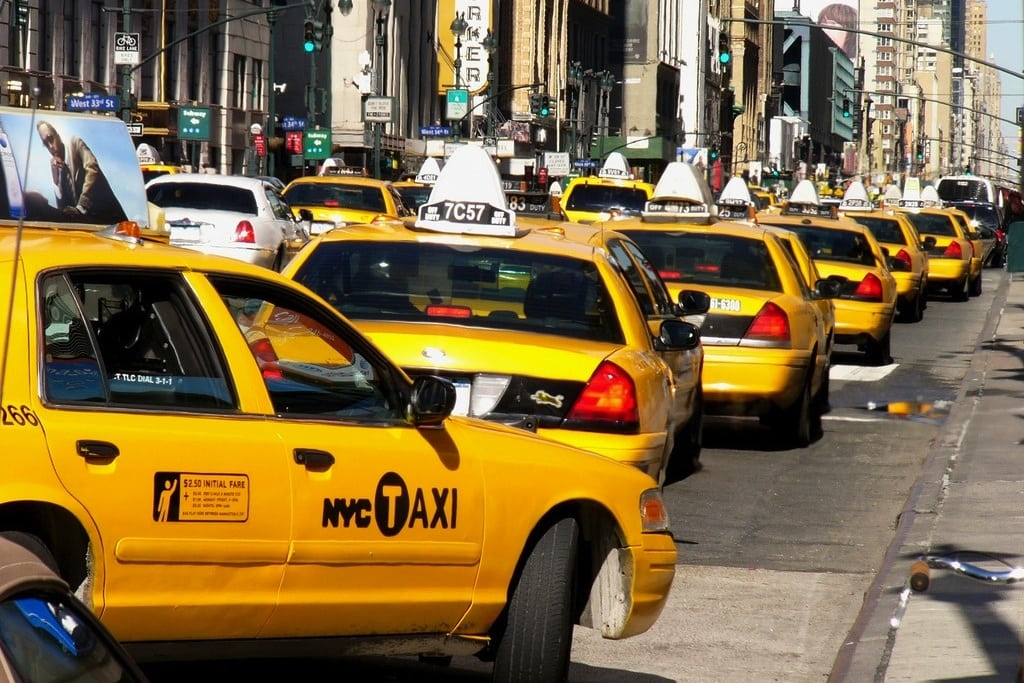

# 1. **Pembahasan**

## 1.1 Latar Belakang

Industri taksi di New York City (NYC) memainkan peran penting dalam mendukung mobilitas warga dan pengunjung kota. Namun, dengan jumlah taksi yang terbatas dan permintaan yang terus meningkat, terutama pada jam sibuk, ada tantangan besar dalam memastikan distribusi armada yang efisien. Selain itu, kehadiran pesaing, seperti layanan transportasi berbasis aplikasi, semakin memperketat persaingan dalam hal layanan dan ketersediaan armada. Untuk tetap kompetitif dan memastikan kualitas layanan, optimalisasi armada yang berbasis data menjadi sangat penting.

Sebagai badan yang bertanggung jawab untuk mengatur industri ini, NYC Taxi and Limousine Commission (NYC TLC) berupaya untuk meningkatkan efektivitas armada taksi dengan memanfaatkan analisis data perjalanan taksi yang telah terkumpul. Melalui penggunaan data historis yang mencatat perjalanan taksi di berbagai borough, NYC TLC dapat lebih memahami pola perjalanan, jam sibuk, dan potensi pendapatan yang dapat dihasilkan.

Masalah utama yang dihadapi adalah bagaimana menyesuaikan jumlah armada dengan permintaan yang berubah-ubah di berbagai borough, baik pada jam sibuk di hari kerja maupun pada weekend. Selain itu, perlu juga untuk mengidentifikasi potensi pendapatan yang dapat dimaksimalkan selama periode jam sibuk di setiap borough, serta bagaimana penempatan armada taksi dapat dioptimalkan untuk memenuhi permintaan yang meningkat dan tetap bersaing dengan penyedia layanan transportasi lainnya.

Dengan menganalisis data perjalanan yang tersedia, NYC TLC berharap dapat mengembangkan strategi yang lebih efektif untuk mengoptimalkan distribusi armada dan memaksimalkan pendapatan di setiap borough, sambil memastikan pelayanan yang cepat, efisien, dan tetap kompetitif dalam menghadapi tantangan dari pesaing.

## 1.2 Problem Statement

Hal yang akan dianalisis berdasarkan latar belakang ini merupakan:

### 1. **Menentukan Jam Sibuk Bagi Tiap Borough NYC**
**Deskripsi:**  
Analisis jam sibuk di setiap borough di New York City untuk memahami pola perjalanan taksi selama periode waktu tertentu. Tujuan utama dari analisis ini adalah untuk mengidentifikasi waktu sibuk berdasarkan jumlah perjalanan yang tercatat di tiap borough, sehingga dapat membantu dalam penyesuaian armada taksi sesuai dengan waktu permintaan tertinggi.

### 2. **Optimasi Penempatan Armada Taksi Berdasarkan Jam Sibuk di NYC**
**Deskripsi:**  
Melakukan optimasi penempatan armada taksi di New York City dengan mempertimbangkan jam sibuk yang teridentifikasi di masing-masing borough. Analisis ini bertujuan untuk memastikan armada terdistribusi secara efisien, dengan lebih banyak taksi ditempatkan di area yang mengalami lonjakan permintaan, sehingga dapat mengurangi waktu tunggu dan meningkatkan kepuasan penumpang.

### 3. **Mengidentifikasi Potensi Pendapatan Berdasarkan Proporsi Jam Sibuk di Setiap Borough**
**Deskripsi:**  
Analisis potensi pendapatan yang dapat dihasilkan selama jam sibuk di tiap borough. Dengan mengidentifikasi jam sibuk dan membandingkan kontribusi pendapatan di tiap periode, dapat ditemukan peluang untuk meningkatkan efisiensi operasional dan pendapatan, serta menentukan langkah strategis untuk meningkatkan layanan taksi di waktu-waktu dengan permintaan tinggi.


# 2. Pembahasan

## 2.1 Import Data

In [9]:
# Import Libraries
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import math
import missingno as msno

from scipy.stats import shapiro

from sklearn.impute import SimpleImputer

pd.set_option('display.max_rows',101)

warnings.filterwarnings('ignore')

In [10]:
# Load Data
df = pd.read_csv('NYC TLC Trip Record.csv')
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,NaN,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,NaN,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,NaN,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,NaN,1.0,19.18,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

Berikut merupakan penjelasan yang tersedia dari kolom-kolom yang ada:

| **Feature**            | **Description**                                                                                                                                                    |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **VendorID**           | A code indicating the LPEP provider that provided the record. <br> 1 = Creative Mobile Technologies, LLC. <br> 2 = VeriFone Inc.                                   |
| **lpep_pickup_datetime** | The date and time when the meter was engaged.                                                                                                                      |
| **lpep_dropoff_datetime** | The date and time when the meter was disengaged.                                                                                                                   |
| **Passenger_count**    | The number of passengers in the vehicle. This is a driver-entered value.                                                                                           |
| **Trip_distance**      | The elapsed trip distance in miles was reported by the taximeter.                                                                                                  |
| **PULocationID**       | TLC Taxi Zone in which the taximeter was engaged.                                                                                                                 |
| **DOLocationID**       | TLC Taxi Zone in which the taximeter was disengaged.                                                                                                               |
| **RateCodeID**         | The final rate code in effect at the end of the trip. <br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br> 4 = Nassau or Westchester <br> 5 = Negotiated fare <br> 6 = Group ride |
| **Store_and_fwd_flag** | This flag indicates whether the trip record was held in the vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server. <br> Y = store and forward trip <br> N = not a store and forward trip |
| **Payment_type**       | A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br> 2 = Cash <br> 3 = No charge <br> 4 = Dispute <br> 5 = Unknown <br> 6 = Voided trip               |
| **Fare_amount**        | The time-and-distance fare calculated by the meter. <br> Extra miscellaneous extras and surcharges. Currently, this includes the $0.50 and $1 rush hour and overnight charges. |
| **MTA_tax**            | \$0.50 MTA tax that is automatically triggered based on the metered rate in use.                                                                                   |
| **Improvement_surcharge** | \$1.00 improvement surcharge assessed on hailed trips at the flag drop. The improvement surcharge began being levied in 2015.                                         |
| **Tip_amount**         | This field is automatically populated for credit card tips. Cash tips are not included.                                                                           |
| **Tolls_amount**       | The total amount of all tolls paid in the trip.                                                                                                                   |
| **Total_amount**       | The total amount charged to passengers. Does not include cash tips.                                                                                                |
| **Trip_type**          | A code indicating whether the trip was a street hail or a dispatch that is automatically assigned based on the metered rate in use but can be altered by the driver. <br> 1 = Street-hail <br> 2 = Dispatch |


Selanjutnya, akan ditambahkan dataset `taxi_zone.csv` yang menyediakan informasi tentang nama borough dan zona untuk lokasi penjemputan (pickup) dan pengantaran (drop-off).

In [15]:
df_taxi_zone = pd.read_csv("taxi+_zone_lookup.csv")
display(df_taxi_zone)
display(df_taxi_zone.info())

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NV,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       265 non-null    object
 2   Zone          264 non-null    object
 3   service_zone  263 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


None

Berikut adalah penjelasan untuk **LocationID**, **Borough**, **Zone**, dan **service_zone** dalam format markdown:

| **Feature**       | **Description**                                                                                                                                     |
|-------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------|
| **LocationID**    | A unique identifier for a specific taxi location, typically assigned by the taxi or zone management system.                                         |
| **Borough**       | The name of the borough (area) in which the taxi was operating. In New York City, this refers to one of the five boroughs: Manhattan, Brooklyn, Queens, Bronx, Staten Island. |
| **Zone**          | Refers to the specific service area or geographical zone within the borough where the taxi operates, often associated with a specific fare structure. |
| **service_zone**  | Indicates the type of service zone, such as whether the zone is within a residential, commercial, or airport zone. This can impact the fare rates.   |

Selanjutnya, akan dimasukkan data `df_taxi_zone` ke `df` berdasarkan `PULocationID` dan `DOLocationID`

In [18]:
# Gabungkan berdasarkan PULocationID
df = df.merge(df_taxi_zone, left_on="PULocationID", right_on="LocationID", how="left")
df.drop("LocationID", axis=1, inplace=True)
df.rename(columns={"Borough": "PUBorough", "Zone": "PUZone", "service_zone": "PUService_Zone"}, inplace=True)

# Gabungkan berdasarkan DOLocationID
df = df.merge(df_taxi_zone, left_on="DOLocationID", right_on="LocationID", how="left")
df.drop("LocationID", axis=1, inplace=True)
df.rename(columns={"Borough": "DOBorough", "Zone": "DOZone", "service_zone": "DOService_Zone"}, inplace=True)

df


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,total_amount,payment_type,trip_type,congestion_surcharge,PUBorough,PUZone,PUService_Zone,DOBorough,DOZone,DOService_Zone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,...,24.18,1.0,1.0,2.75,Manhattan,Morningside Heights,Boro Zone,Manhattan,Lincoln Square West,Yellow Zone
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,...,15.84,1.0,1.0,0.00,Manhattan,Bloomingdale,Yellow Zone,Manhattan,Central Park,Yellow Zone
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,...,11.64,1.0,1.0,0.00,Queens,Steinway,Boro Zone,Queens,Old Astoria,Boro Zone
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,...,10.20,1.0,1.0,0.00,Manhattan,Central Harlem,Boro Zone,Manhattan,Upper West Side North,Yellow Zone
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,...,8.00,1.0,1.0,0.00,Manhattan,Central Harlem,Boro Zone,Manhattan,East Harlem North,Boro Zone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,...,16.70,NaN,NaN,NaN,Brooklyn,Clinton Hill,Boro Zone,Brooklyn,Crown Heights South,Boro Zone
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,...,5.41,NaN,NaN,NaN,Queens,Baisley Park,Boro Zone,Queens,Saint Albans,Boro Zone
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,...,21.04,NaN,NaN,NaN,Brooklyn,DUMBO/Vinegar Hill,Boro Zone,Brooklyn,Bushwick South,Boro Zone
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,...,19.18,NaN,NaN,NaN,Brooklyn,Stuyvesant Heights,Boro Zone,Brooklyn,Prospect Heights,Boro Zone


## 2.2 Missing Value

Pada bagian ini akan dilakukan penanganan terhadap missing value

In [21]:
# Menghitung jumlah nilai kosong
missing_values = df.isnull().sum()

# Menghitung persentase nilai kosong
missing_percentage = (missing_values / len(df)) * 100

# Membuat DataFrame untuk melihat hasilnya dengan rapi
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

# Menampilkan DataFrame
missing_summary

,Missing Values,Percentage
VendorID,0,0.000000
lpep_pickup_datetime,0,0.000000
lpep_dropoff_datetime,0,0.000000
store_and_fwd_flag,4324,6.339154
RatecodeID,4324,6.339154
PULocationID,0,0.000000
DOLocationID,0,0.000000
passenger_count,4324,6.339154
trip_distance,0,0.000000
fare_amount,0,0.000000


Dapat dilihat bahwa kolom `ehail_fee` memiliki missing value sebesar 100%, lalu pada kolom `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`, `trip_type`, dan `congestion_surcharge` memiliki missing value sebesar 6.33%

<Axes: >

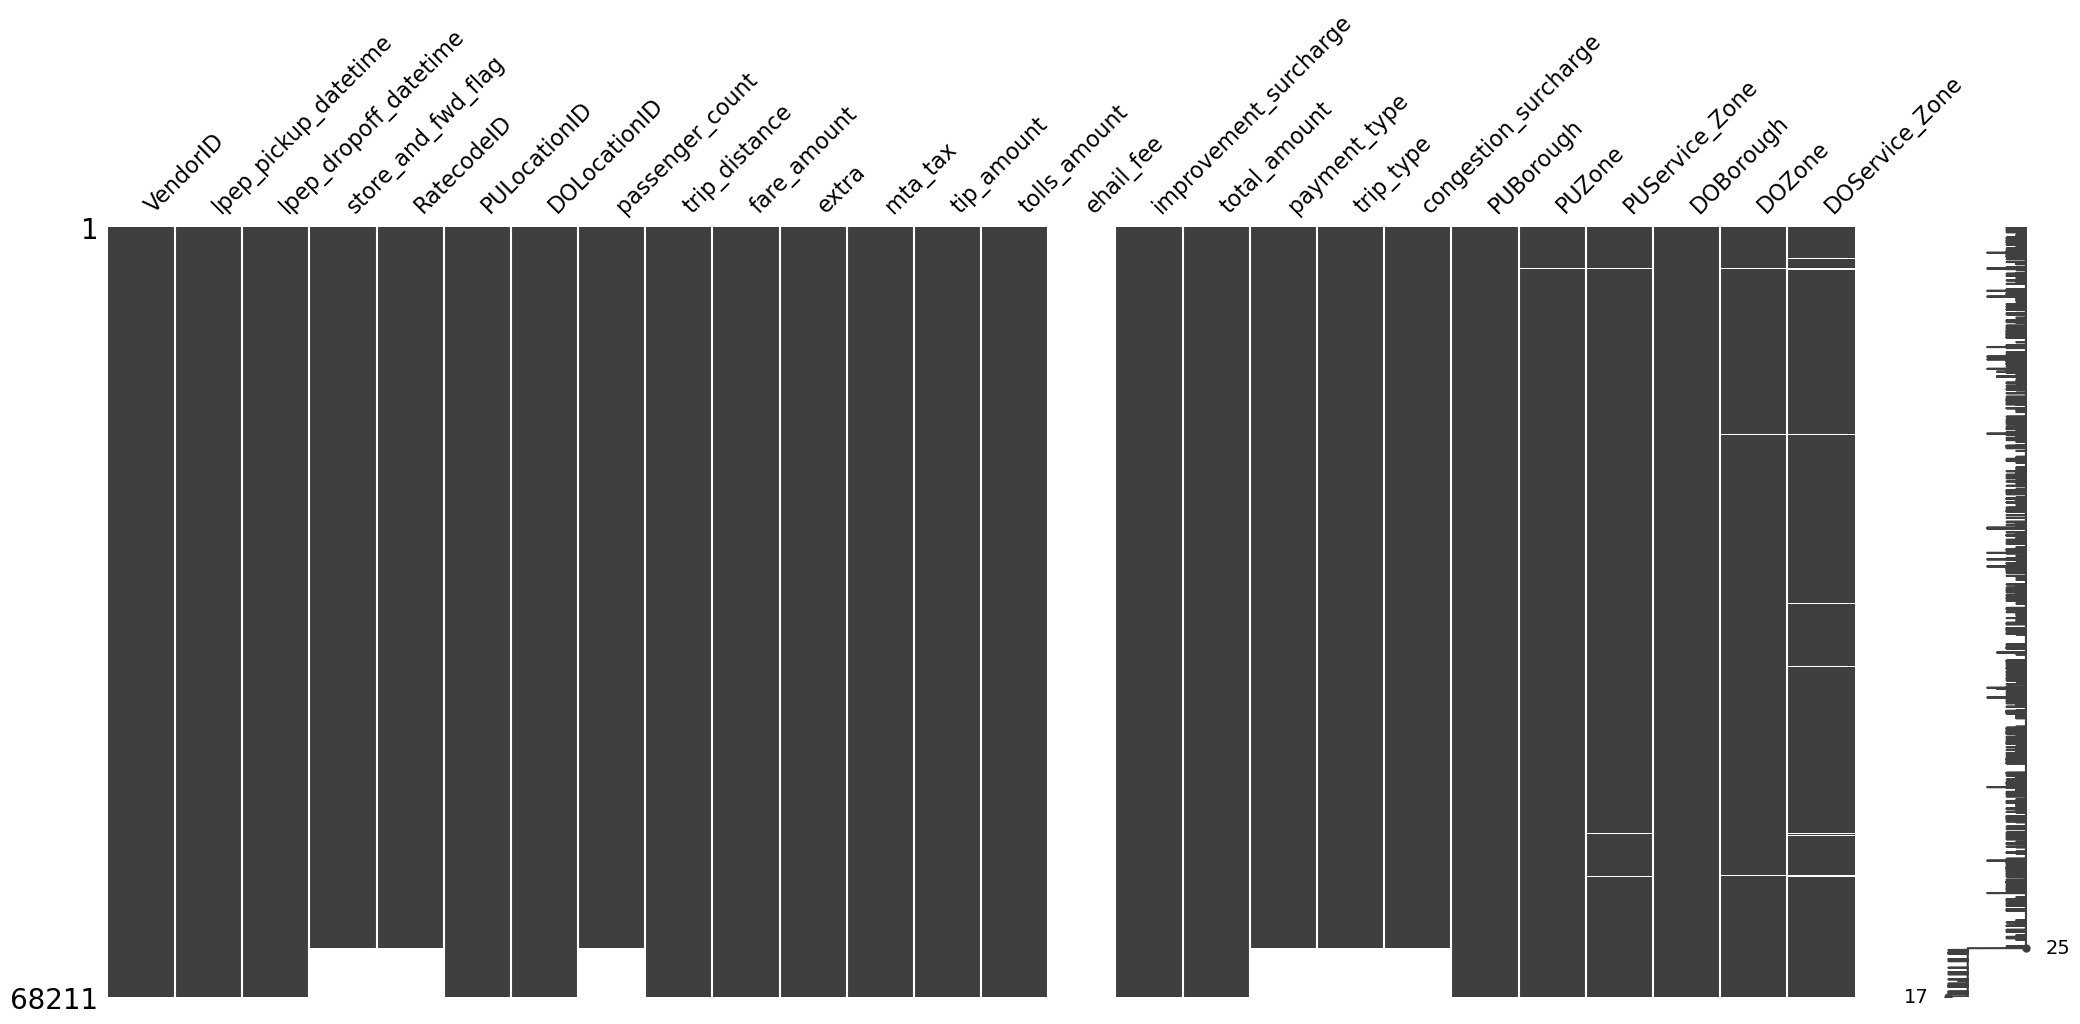

In [23]:
msno.matrix(df)

Karena kolom `ehail_fee` memiliki missing value sebesar 100% maka kolom tersebut akan di drop. Adanya kemungkinan fitur ini kosong dikarenakan customer tidak dikenakan `ehail_fee` sehingga datanya kosong

In [25]:
# Drop kolom ehail_fee karena missing valuenya 100%
df.drop("ehail_fee", axis=1, inplace=True)

Selanjutnya melihat kolom `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`, `trip_type`, dan `congestion_surcharge` yang memiliki missing value.

In [27]:
# Pilih kolom yang ingin diperiksa
columns_to_check = ['store_and_fwd_flag', 'RatecodeID', 'passenger_count', 'payment_type', 'trip_type', 'congestion_surcharge']

# Filter baris yang memiliki missing value di kolom tersebut
missing_values = df[df[columns_to_check].isnull().any(axis=1)]

# Tampilkan hasil
missing_values[columns_to_check]

,store_and_fwd_flag,RatecodeID,passenger_count,payment_type,trip_type,congestion_surcharge
1084,N,99.0,1.0,1.0,NaN,0.0
2174,N,99.0,1.0,1.0,NaN,0.0
9055,N,99.0,1.0,1.0,NaN,0.0
14125,N,99.0,1.0,1.0,NaN,0.0
29143,N,99.0,1.0,1.0,NaN,0.0
...,...,...,...,...,...,...
68206,NaN,NaN,NaN,NaN,NaN,NaN
68207,NaN,NaN,NaN,NaN,NaN,NaN
68208,NaN,NaN,NaN,NaN,NaN,NaN
68209,NaN,NaN,NaN,NaN,NaN,NaN


Dapat dilihat bahwa 6 kolom tersebut memiliki missing value di baris yang bersamaaan, Hal ini dapat terjadi karena adanya kesalahana pada saat penginputan. Karena data yang missing hanya sebesar 6.33% maka data yang missing akan di drop.

In [29]:
# Drop yang memiliki missing value
df.dropna(inplace=True)

Setelah dilakukan drop pada missing value maka dapat dilihat bahwa data sudah tidak memiliki missing value,.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63186 entries, 0 to 63886
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               63186 non-null  int64  
 1   lpep_pickup_datetime   63186 non-null  object 
 2   lpep_dropoff_datetime  63186 non-null  object 
 3   store_and_fwd_flag     63186 non-null  object 
 4   RatecodeID             63186 non-null  float64
 5   PULocationID           63186 non-null  int64  
 6   DOLocationID           63186 non-null  int64  
 7   passenger_count        63186 non-null  float64
 8   trip_distance          63186 non-null  float64
 9   fare_amount            63186 non-null  float64
 10  extra                  63186 non-null  float64
 11  mta_tax                63186 non-null  float64
 12  tip_amount             63186 non-null  float64
 13  tolls_amount           63186 non-null  float64
 14  improvement_surcharge  63186 non-null  float64
 15  total_a

## 2.3 Data Types

Di bagian ini akan dilakukan penyesuaian data type untuk setiap kolom

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63186 entries, 0 to 63886
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               63186 non-null  int64  
 1   lpep_pickup_datetime   63186 non-null  object 
 2   lpep_dropoff_datetime  63186 non-null  object 
 3   store_and_fwd_flag     63186 non-null  object 
 4   RatecodeID             63186 non-null  float64
 5   PULocationID           63186 non-null  int64  
 6   DOLocationID           63186 non-null  int64  
 7   passenger_count        63186 non-null  float64
 8   trip_distance          63186 non-null  float64
 9   fare_amount            63186 non-null  float64
 10  extra                  63186 non-null  float64
 11  mta_tax                63186 non-null  float64
 12  tip_amount             63186 non-null  float64
 13  tolls_amount           63186 non-null  float64
 14  improvement_surcharge  63186 non-null  float64
 15  total_a

Dapat dilihat bahwa data type pada dataset masih belum semua sesuai, maka dari itu akan dilakukan penyesuaian pada data type.

Untuk kolom `lpep_pickup_datetime` dan `lpep_dropoff_datetime` masih berupa object dan akan kita ubah ke datetime

In [37]:
# Mengonversi kolom menjadi datetime
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

Untuk kolom `VendorID`, `store_and_fwd_flag`, `RatecodeID`, `PULocationID`, `DOLocationID`, `payment_type`, dan `trip_type` masih berupa integer serta object dan akan kita ubah ke category

In [39]:
# Mengonversi kolom menjadi category
df['VendorID'] = df['VendorID'].astype('category')
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype('category')
df['RatecodeID'] = df['RatecodeID'].astype('category')
df['PULocationID'] = df['PULocationID'].astype('category')
df['DOLocationID'] = df['DOLocationID'].astype('category')
df['payment_type'] = df['payment_type'].astype('category')
df['trip_type'] = df['trip_type'].astype('category')

Kolom `passenger_count` akan diubah menjadi tipe integer karena nilai dalam kolom tersebut mewakili jumlah penumpang dalam perjalanan, yang secara alami adalah bilangan bulat (integer).

In [41]:
# Mengonversi kolom menjadi integer
df['passenger_count'] = df['passenger_count'].astype('int')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63186 entries, 0 to 63886
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               63186 non-null  category      
 1   lpep_pickup_datetime   63186 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  63186 non-null  datetime64[ns]
 3   store_and_fwd_flag     63186 non-null  category      
 4   RatecodeID             63186 non-null  category      
 5   PULocationID           63186 non-null  category      
 6   DOLocationID           63186 non-null  category      
 7   passenger_count        63186 non-null  int64         
 8   trip_distance          63186 non-null  float64       
 9   fare_amount            63186 non-null  float64       
 10  extra                  63186 non-null  float64       
 11  mta_tax                63186 non-null  float64       
 12  tip_amount             63186 non-null  float64       
 13  tolls_

Dapat dilihat bahwa data type dari setiap kolom terganti sesuai dengan yang telah dilakukan.

## 2.4 Duplicate Check

Di bagian ini, akan dilakukan cek duplikasi pada dataset untuk memastikan tidak ada entri data yang berulang, yang dapat memengaruhi hasil analisis.

In [46]:
# Cek banyaknya duplikat
df.duplicated().sum()

0

Diemukan banyak duplikat sebanyak 47. Untuk menindaklanjutinya, data duplikat akan dihapus agar dataset menjadi bersih dan analisis selanjutnya dapat dilakukan secara akurat tanpa dipengaruhi oleh entri yang berulang.

In [48]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Validasi setelah penghapusan
print(f"Jumlah data yang duplikat setelah dilakukan penghapusan duplikat: {df.duplicated().sum()}")


Jumlah data yang duplikat setelah dilakukan penghapusan duplikat: 0


## 2.5 Range Check

Di bagian ini akan dilakukan range check untuk memastikan bahwa nilai yang dimasukkan berada dalam rentang yang valid.

In [51]:
df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,63186,63186,63186.000000,63186.000000,63186.000000,63186.000000,63186.000000,63186.000000,63186.000000,63186.000000,63186.000000,63186.000000
mean,2023-01-16 20:37:37.026382336,2023-01-16 20:55:32.173376768,1.317064,2.552158,15.867675,0.886074,0.628600,2.036018,0.139439,0.949902,20.998919,0.734332
min,2009-01-01 20:21:27,2009-01-02 11:07:31,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,-1.000000,-71.500000,-2.750000
25%,2023-01-09 12:35:22.750000128,2023-01-09 12:48:44.500000,1.000000,1.100000,9.000000,0.000000,0.500000,0.000000,0.000000,1.000000,12.600000,0.000000
50%,2023-01-17 08:47:56.500000,2023-01-17 09:04:16.500000,1.000000,1.800000,12.800000,0.000000,0.500000,1.460000,0.000000,1.000000,17.450000,0.000000
75%,2023-01-24 16:21:54.750000128,2023-01-24 16:38:17,1.000000,3.040000,19.100000,1.000000,0.500000,3.220000,0.000000,1.000000,25.300000,2.750000
max,2023-02-01 03:10:05,2023-02-01 17:27:05,9.000000,1571.970000,490.000000,7.500000,2.750000,222.220000,36.050000,1.000000,491.000000,2.750000
std,NaN,NaN,0.980606,6.729548,12.497043,1.294992,0.364154,2.923970,0.981722,0.199981,14.380570,1.216862


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63186 entries, 0 to 63886
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               63186 non-null  category      
 1   lpep_pickup_datetime   63186 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  63186 non-null  datetime64[ns]
 3   store_and_fwd_flag     63186 non-null  category      
 4   RatecodeID             63186 non-null  category      
 5   PULocationID           63186 non-null  category      
 6   DOLocationID           63186 non-null  category      
 7   passenger_count        63186 non-null  int64         
 8   trip_distance          63186 non-null  float64       
 9   fare_amount            63186 non-null  float64       
 10  extra                  63186 non-null  float64       
 11  mta_tax                63186 non-null  float64       
 12  tip_amount             63186 non-null  float64       
 13  tolls_

Terlihat bahwa pada kolom `lpep_pickup_datetime` dan `lpep_dropoff_datetime` terdapat data yang mencakup periode sebelum dan sesudah 2023-01-01. Karena data ini hanya berentang pada bulan Januari tahun 2023, maka data di luar rentang waktu tersebut akan dihapus.

In [54]:
# Filter data hanya yang berada di bulan Januari 2023
df = df[(df["lpep_pickup_datetime"] >= "2023-01-01") & (df["lpep_pickup_datetime"] < "2023-02-01") &
        (df["lpep_dropoff_datetime"] >= "2023-01-01") & (df["lpep_dropoff_datetime"] < "2023-02-01")]
df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,63169,63169,63169.000000,63169.000000,63169.000000,63169.000000,63169.000000,63169.000000,63169.000000,63169.000000,63169.000000,63169.000000
mean,2023-01-16 22:31:31.191074816,2023-01-16 22:49:16.015181568,1.317070,2.551858,15.866734,0.886147,0.628643,2.036094,0.139373,0.949933,20.998136,0.734399
min,2023-01-01 00:01:31,2023-01-01 00:13:26,0.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,-1.000000,-71.500000,-2.750000
25%,2023-01-09 12:35:13,2023-01-09 12:48:39,1.000000,1.100000,9.000000,0.000000,0.500000,0.000000,0.000000,1.000000,12.600000,0.000000
50%,2023-01-17 08:47:31,2023-01-17 09:03:06,1.000000,1.800000,12.800000,0.000000,0.500000,1.460000,0.000000,1.000000,17.450000,0.000000
75%,2023-01-24 16:18:41,2023-01-24 16:36:36,1.000000,3.040000,19.100000,1.000000,0.500000,3.220000,0.000000,1.000000,25.300000,2.750000
max,2023-01-31 23:45:10,2023-01-31 23:55:05,9.000000,1571.970000,490.000000,7.500000,2.750000,222.220000,36.050000,1.000000,491.000000,2.750000
std,NaN,NaN,0.980693,6.730284,12.497074,1.295066,0.364188,2.924098,0.981520,0.199940,14.380734,1.216897


Karena `lpep_pickup_datetime` merupakan waktu penumpang naik taksi dan `lpep_dropoff_datetime` merupakan waktu penumpang turun, maka kita akan melihat mana saja data yang memiliki `lpep_dropoff_datetime` lebih awal dari `lpep_pickup_datetime`.

In [56]:
# Menghitung jumlah data dimana lpep_dropoff_datetime lebih kecil dari lpep_pickup_datetime
count_invalid = (df['lpep_dropoff_datetime'] < df['lpep_pickup_datetime']).sum()

# Menghitung persentase data dimana lpep_dropoff_datetime lebih kecil dari lpep_pickup_datetime
percentage_invalid = (count_invalid / len(df)) * 100

# Menampilkan hasil
print(f'Jumlah data dimana lpep_dropoff_datetime lebih kecil dari lpep_pickup_datetime: {count_invalid}')
print(f'Persentase data dimana lpep_dropoff_datetime lebih kecil dari lpep_pickup_datetime: {percentage_invalid:.2f}%')


Jumlah data dimana lpep_dropoff_datetime lebih kecil dari lpep_pickup_datetime: 0
Persentase data dimana lpep_dropoff_datetime lebih kecil dari lpep_pickup_datetime: 0.00%


Terlihat bahwa tidak ada keanehan pada data yang memiliki lpep_dropoff_datetime lebih awal dari lpep_pickup_datetime, semua data sudah sesuai dengan urutan waktu yang diharapkan.

Karena data tersebut sudah tidak memiliki keanehan maka akan ditambahkan kolom baru berupa `trip_distance(minute)` yang merupakan selisih waktu antara `lpep_dropoff_datetime` dengan `lpep_pickup_datetime` untuk kegunaan analisa ke depannya.

In [59]:
# Mengonversi kolom waktu pickup dan dropoff ke datetime
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

# Menghitung durasi perjalanan dalam menit
df['trip_duration'] = (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds() / 60

# Menghitung format MM:SS secara langsung tanpa kolom terpisah
df['trip_duration_formatted'] = (df['trip_duration'] // 1).astype(int).astype(str) + ':' + ((df['trip_duration'] % 1) * 60).round().astype(int).astype(str).str.zfill(2)

# Menampilkan hasil
df[['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'trip_duration_formatted']].head()


,lpep_pickup_datetime,lpep_dropoff_datetime,trip_duration_formatted
0,2023-01-01 00:26:10,2023-01-01 00:37:11,11:01
1,2023-01-01 00:51:03,2023-01-01 00:57:49,6:46
2,2023-01-01 00:35:12,2023-01-01 00:41:32,6:20
3,2023-01-01 00:13:14,2023-01-01 00:19:03,5:49
4,2023-01-01 00:33:04,2023-01-01 00:39:02,5:58


In [60]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,trip_type,congestion_surcharge,PUBorough,PUZone,PUService_Zone,DOBorough,DOZone,DOService_Zone,trip_duration,trip_duration_formatted
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1,2.58,14.9,...,1.0,2.75,Manhattan,Morningside Heights,Boro Zone,Manhattan,Lincoln Square West,Yellow Zone,11.016667,11:01
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1,1.81,10.7,...,1.0,0.00,Manhattan,Bloomingdale,Yellow Zone,Manhattan,Central Park,Yellow Zone,6.766667,6:46
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1,0.00,7.2,...,1.0,0.00,Queens,Steinway,Boro Zone,Queens,Old Astoria,Boro Zone,6.333333,6:20
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1,1.30,6.5,...,1.0,0.00,Manhattan,Central Harlem,Boro Zone,Manhattan,Upper West Side North,Yellow Zone,5.816667,5:49
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1,1.10,6.0,...,1.0,0.00,Manhattan,Central Harlem,Boro Zone,Manhattan,East Harlem North,Boro Zone,5.966667,5:58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63882,2,2023-01-31 23:09:22,2023-01-31 23:17:21,N,5.0,130,205,1,2.75,15.0,...,2.0,0.00,Queens,Jamaica,Boro Zone,Queens,Saint Albans,Boro Zone,7.983333,7:59
63883,2,2023-01-31 23:06:18,2023-01-31 23:17:03,N,1.0,65,181,1,2.44,13.5,...,1.0,0.00,Brooklyn,Downtown Brooklyn/MetroTech,Boro Zone,Brooklyn,Park Slope,Boro Zone,10.750000,10:45
63884,2,2023-01-31 23:17:03,2023-01-31 23:23:04,N,1.0,244,116,1,1.40,9.3,...,1.0,0.00,Manhattan,Washington Heights South,Boro Zone,Manhattan,Hamilton Heights,Boro Zone,6.016667,6:01
63885,2,2023-01-31 23:29:18,2023-01-31 23:38:50,N,1.0,74,238,1,2.47,13.5,...,1.0,2.75,Manhattan,East Harlem North,Boro Zone,Manhattan,Upper West Side North,Yellow Zone,9.533333,9:32


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63169 entries, 0 to 63886
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   VendorID                 63169 non-null  category      
 1   lpep_pickup_datetime     63169 non-null  datetime64[ns]
 2   lpep_dropoff_datetime    63169 non-null  datetime64[ns]
 3   store_and_fwd_flag       63169 non-null  category      
 4   RatecodeID               63169 non-null  category      
 5   PULocationID             63169 non-null  category      
 6   DOLocationID             63169 non-null  category      
 7   passenger_count          63169 non-null  int64         
 8   trip_distance            63169 non-null  float64       
 9   fare_amount              63169 non-null  float64       
 10  extra                    63169 non-null  float64       
 11  mta_tax                  63169 non-null  float64       
 12  tip_amount               63169 non-nu

Pada bagian `passenger_count`, sesuai dengan yang tertera pada website NYC TLC  bahwa maksimal penumpang merupakan 5 orang. Maka dari itu penumpang dibawah 1 dan di atas 5 akan ditelusuri lebih lanjut.

sumber: https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page#:~:text=The%20maximum%20amount%20of%20passengers,ride%20in%20child%20safety%20seats.

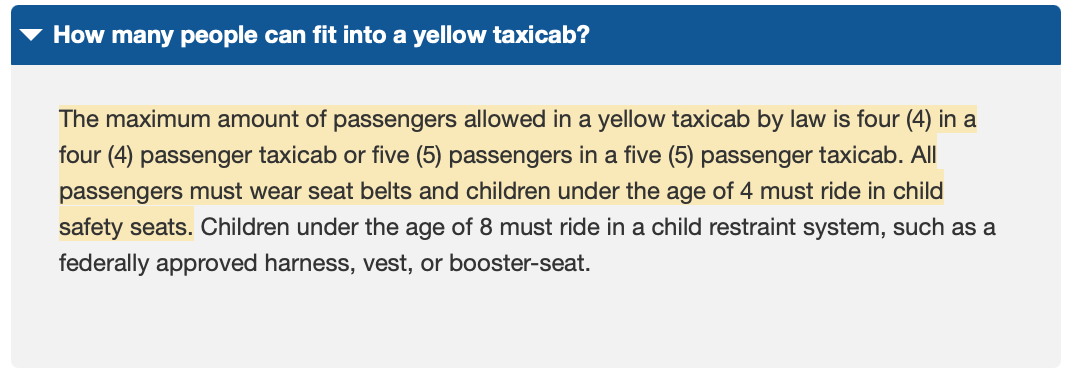

In [64]:
# Memeriksa data passenger_count yang kurang dari 1 atau lebih dari 5
invalid_passenger_count = df[(df['passenger_count'] < 1) | (df['passenger_count'] > 5)]

# Menghitung jumlah dan persentase data yang invalid
total_invalid = len(invalid_passenger_count)
total_data = len(df)
percentage_invalid = (total_invalid / total_data) * 100

# Menampilkan jumlah dan persentase
print(f'Jumlah data dengan passenger_count kurang dari 1 atau lebih dari 5: {total_invalid}')
print(f'Persentase data yang invalid: {percentage_invalid:.2f}%')


Jumlah data dengan passenger_count kurang dari 1 atau lebih dari 5: 1378
Persentase data yang invalid: 2.18%


Karena ada data yang tidak sesuai range dan datanya sebesar 2.18%, maka data tersebut akan di drop

In [66]:
# Drop data dengan passenger_count yang kurang dari 1 atau lebih dari 5
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 5)]

df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
count,61791,61791,61791.000000,61791.000000,61791.000000,61791.000000,61791.000000,61791.000000,61791.000000,61791.000000,61791.000000,61791.000000,61791.000000
mean,2023-01-16 22:41:23.569888768,2023-01-16 22:59:15.831593728,1.243741,2.557178,15.900663,0.889640,0.626786,2.036133,0.138615,0.949248,21.031649,0.731061,17.871028
min,2023-01-01 00:01:31,2023-01-01 00:16:02,1.000000,0.000000,-70.000000,-2.500000,-0.500000,-10.500000,0.000000,-1.000000,-71.500000,-2.750000,0.000000
25%,2023-01-09 12:45:39.500000,2023-01-09 13:00:48,1.000000,1.100000,9.300000,0.000000,0.500000,0.000000,0.000000,1.000000,12.600000,0.000000,7.133333
50%,2023-01-17 08:47:44,2023-01-17 09:03:53,1.000000,1.800000,12.800000,0.000000,0.500000,1.460000,0.000000,1.000000,17.460000,0.000000,11.116667
75%,2023-01-24 16:26:58,2023-01-24 16:43:16,1.000000,3.050000,19.100000,1.000000,0.500000,3.220000,0.000000,1.000000,25.350000,2.750000,16.833333
max,2023-01-31 23:45:10,2023-01-31 23:55:05,5.000000,1571.970000,490.000000,7.500000,2.750000,222.220000,36.050000,1.000000,491.000000,2.750000,1439.883333
std,NaN,NaN,0.769524,6.796500,12.549396,1.295084,0.362437,2.932462,0.978117,0.201234,14.426917,1.215140,76.637735


In [67]:
# Memeriksa data trip_distance yang sama dengan 0
invalid_trip_distance = df[df['trip_distance'] == 0]

# Menghitung jumlah dan persentase data yang invalid
total_invalid = len(invalid_trip_distance)
total_data = len(df)
percentage_invalid = (total_invalid / total_data) * 100

# Menampilkan jumlah dan persentase
print(f'Jumlah data dengan trip_distance = 0: {total_invalid}')
print(f'Persentase data yang invalid: {percentage_invalid:.2f}%')


Jumlah data dengan trip_distance = 0: 2788
Persentase data yang invalid: 4.51%


Karena data dengan `trip_distance` yang memiliki nilai 0 sebanyak 2788 dengan persentase data 4.51%, maka diputuskan bahwa data akan di drop karena bila ditangani dengan simple imputer akan mempengaruhi kolom-kolom yang lain sehingga amannya di drop.

In [69]:
# Drop data dengan trip_distance yang sama dengan 0
df = df[df['trip_distance'] != 0]

df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
count,59003,59003,59003.000000,59003.000000,59003.000000,59003.000000,59003.000000,59003.00000,59003.000000,59003.000000,59003.000000,59003.000000,59003.000000
mean,2023-01-16 23:03:10.145975552,2023-01-16 23:20:58.205277440,1.250157,2.678010,15.729233,0.917203,0.614748,2.09619,0.124221,0.951647,20.962887,0.758661,17.800988
min,2023-01-01 00:01:31,2023-01-01 00:16:02,1.000000,0.010000,-70.000000,-2.500000,-0.500000,0.00000,0.000000,-1.000000,-71.500000,-2.750000,0.000000
25%,2023-01-09 12:46:12,2023-01-09 13:00:20.500000,1.000000,1.200000,9.300000,0.000000,0.500000,0.00000,0.000000,1.000000,12.620000,0.000000,7.250000
50%,2023-01-17 09:16:45,2023-01-17 09:33:34,1.000000,1.880000,12.800000,0.000000,0.500000,1.62000,0.000000,1.000000,17.450000,0.000000,11.133333
75%,2023-01-24 16:36:50.500000,2023-01-24 16:53:42,1.000000,3.150000,18.400000,2.500000,0.500000,3.28000,0.000000,1.000000,25.200000,2.750000,16.666667
max,2023-01-31 23:45:10,2023-01-31 23:55:05,5.000000,1571.970000,455.000000,7.500000,1.500000,222.22000,36.050000,1.000000,456.000000,2.750000,1438.933333
std,NaN,NaN,0.780878,6.931921,11.465721,1.305124,0.340267,2.93688,0.922226,0.190218,13.560505,1.229380,76.860032


Dapat dilihat juga bahwa `fare_amount` memiliki nilai yang negatif, maka dari itu akan ditelusuri lebih lanjut.

In [71]:
# Memeriksa data fare_amount yang kurang dari 0
invalid_fare_amount = df[df['fare_amount'] < 0]

# Menghitung jumlah dan persentase data yang invalid
total_invalid = len(invalid_fare_amount)
total_data = len(df)
percentage_invalid = (total_invalid / total_data) * 100

# Menampilkan jumlah dan persentase
print(f'Jumlah data dengan fare_amount < 0: {total_invalid}')
print(f'Persentase data yang invalid: {percentage_invalid:.2f}%')


Jumlah data dengan fare_amount < 0: 98
Persentase data yang invalid: 0.17%


In [72]:
df[df['fare_amount'] < 0]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,trip_type,congestion_surcharge,PUBorough,PUZone,PUService_Zone,DOBorough,DOZone,DOService_Zone,trip_duration,trip_duration_formatted
662,2,2023-01-01 14:58:13,2023-01-01 14:58:39,N,1.0,75,74,2,0.17,-3.0,...,1.0,0.00,Manhattan,East Harlem South,Boro Zone,Manhattan,East Harlem North,Boro Zone,0.433333,0:26
1317,2,2023-01-02 02:05:08,2023-01-02 02:12:57,N,1.0,129,82,1,0.64,-8.6,...,1.0,0.00,Queens,Jackson Heights,Boro Zone,Queens,Elmhurst,Boro Zone,7.816667,7:49
1686,2,2023-01-02 12:56:53,2023-01-02 13:00:10,N,1.0,75,75,1,0.77,-4.5,...,1.0,0.00,Manhattan,East Harlem South,Boro Zone,Manhattan,East Harlem South,Boro Zone,3.283333,3:17
1864,2,2023-01-02 13:51:33,2023-01-02 13:52:42,N,1.0,75,75,2,0.08,-3.7,...,1.0,0.00,Manhattan,East Harlem South,Boro Zone,Manhattan,East Harlem South,Boro Zone,1.150000,1:09
2481,2,2023-01-02 19:03:48,2023-01-02 19:04:24,N,1.0,130,130,1,0.11,-3.0,...,1.0,0.00,Queens,Jamaica,Boro Zone,Queens,Jamaica,Boro Zone,0.600000,0:36
3378,2,2023-01-03 11:30:37,2023-01-03 11:32:23,N,1.0,166,166,2,0.16,-3.7,...,1.0,0.00,Manhattan,Morningside Heights,Boro Zone,Manhattan,Morningside Heights,Boro Zone,1.766667,1:46
3761,2,2023-01-03 14:25:22,2023-01-03 14:27:53,N,1.0,42,42,2,0.32,-4.4,...,1.0,0.00,Manhattan,Central Harlem North,Boro Zone,Manhattan,Central Harlem North,Boro Zone,2.516667,2:31
3780,2,2023-01-03 13:59:49,2023-01-03 14:00:46,N,1.0,7,7,1,0.17,-3.7,...,1.0,0.00,Queens,Astoria,Boro Zone,Queens,Astoria,Boro Zone,0.950000,0:57
3881,2,2023-01-03 15:51:13,2023-01-03 16:00:58,N,1.0,97,97,1,0.59,-10.0,...,1.0,0.00,Brooklyn,Fort Greene,Boro Zone,Brooklyn,Fort Greene,Boro Zone,9.750000,9:45
4820,2,2023-01-04 06:46:52,2023-01-04 06:47:27,N,1.0,129,82,2,0.01,-3.0,...,1.0,0.00,Queens,Jackson Heights,Boro Zone,Queens,Elmhurst,Boro Zone,0.583333,0:35


Diketahui bahwa terdapat sebanyak 98 nilai `fare_amount` yang negatif. Namun, terlihat juga bahwa `fare_amount` negatif ini diikuti dengan nilai negatif pada kolom `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, dan `congestion_surcharge` . Oleh karena itu, perlu dilakukan penelusuran lebih lanjut untuk memverifikasi apakah memang benar bahwa ketika fare_amount negatif, kolom-kolom yang telah disebutkan juga negatif.

In [74]:
# Menyaring data dengan fare_amount negatif
invalid_fare_data = df[df['fare_amount'] < 0]

# Memeriksa apakah kolom lain juga negatif atau 0
invalid_fare_data_check = invalid_fare_data[
    (invalid_fare_data['extra'] <= 0) & 
    (invalid_fare_data['mta_tax'] <= 0) & 
    (invalid_fare_data['tip_amount'] <= 0) & 
    (invalid_fare_data['tolls_amount'] <= 0) & 
    (invalid_fare_data['improvement_surcharge'] <= 0) & 
    (invalid_fare_data['total_amount'] <= 0) &
    (invalid_fare_data['congestion_surcharge'] <= 0)
]

# Menampilkan hasil
display(invalid_fare_data_check)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,trip_type,congestion_surcharge,PUBorough,PUZone,PUService_Zone,DOBorough,DOZone,DOService_Zone,trip_duration,trip_duration_formatted
662,2,2023-01-01 14:58:13,2023-01-01 14:58:39,N,1.0,75,74,2,0.17,-3.0,...,1.0,0.00,Manhattan,East Harlem South,Boro Zone,Manhattan,East Harlem North,Boro Zone,0.433333,0:26
1317,2,2023-01-02 02:05:08,2023-01-02 02:12:57,N,1.0,129,82,1,0.64,-8.6,...,1.0,0.00,Queens,Jackson Heights,Boro Zone,Queens,Elmhurst,Boro Zone,7.816667,7:49
1686,2,2023-01-02 12:56:53,2023-01-02 13:00:10,N,1.0,75,75,1,0.77,-4.5,...,1.0,0.00,Manhattan,East Harlem South,Boro Zone,Manhattan,East Harlem South,Boro Zone,3.283333,3:17
1864,2,2023-01-02 13:51:33,2023-01-02 13:52:42,N,1.0,75,75,2,0.08,-3.7,...,1.0,0.00,Manhattan,East Harlem South,Boro Zone,Manhattan,East Harlem South,Boro Zone,1.150000,1:09
2481,2,2023-01-02 19:03:48,2023-01-02 19:04:24,N,1.0,130,130,1,0.11,-3.0,...,1.0,0.00,Queens,Jamaica,Boro Zone,Queens,Jamaica,Boro Zone,0.600000,0:36
3378,2,2023-01-03 11:30:37,2023-01-03 11:32:23,N,1.0,166,166,2,0.16,-3.7,...,1.0,0.00,Manhattan,Morningside Heights,Boro Zone,Manhattan,Morningside Heights,Boro Zone,1.766667,1:46
3761,2,2023-01-03 14:25:22,2023-01-03 14:27:53,N,1.0,42,42,2,0.32,-4.4,...,1.0,0.00,Manhattan,Central Harlem North,Boro Zone,Manhattan,Central Harlem North,Boro Zone,2.516667,2:31
3780,2,2023-01-03 13:59:49,2023-01-03 14:00:46,N,1.0,7,7,1,0.17,-3.7,...,1.0,0.00,Queens,Astoria,Boro Zone,Queens,Astoria,Boro Zone,0.950000,0:57
3881,2,2023-01-03 15:51:13,2023-01-03 16:00:58,N,1.0,97,97,1,0.59,-10.0,...,1.0,0.00,Brooklyn,Fort Greene,Boro Zone,Brooklyn,Fort Greene,Boro Zone,9.750000,9:45
4820,2,2023-01-04 06:46:52,2023-01-04 06:47:27,N,1.0,129,82,2,0.01,-3.0,...,1.0,0.00,Queens,Jackson Heights,Boro Zone,Queens,Elmhurst,Boro Zone,0.583333,0:35


Dapat dilihat bahwa ternyata benar bahwa ketika `fare_amount` negatif, kolom-kolom lainnya seperti `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `total_amount`, dan `congestion_surcharge` juga memiliki nilai <= 0 dan apabila mereka dijumlahkan, hasil dengan `total_amount` akan sama. Hal ini akan diasumsikan bahwa adanya kesalahan input atau adanya error dalam penginputan. 

Untuk menangani hal ini, nilai-nilai negatif tersebut akan ditangani dengan simple imputer modus bagi kolom : `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, dan `congestion_surcharge`. Lalu untuk kolom `fare_amount` dan `total_amount` di jadikan absolut.

In [76]:
# Kolom yang akan diimputasi dengan modus
impute_columns = ['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge']

# Mengimputasi nilai negatif pada kolom yang disebutkan
for col in impute_columns:
    imputer = SimpleImputer(strategy='most_frequent')
    df[col] = np.where(df[col] < 0, np.nan, df[col])  # Ganti nilai negatif menjadi NaN
    df[col] = imputer.fit_transform(df[[col]])  # Imputasi NaN dengan modus

# Mengubah nilai negatif pada 'fare_amount' dan 'total_amount' menjadi nilai absolut
df['fare_amount'] = df['fare_amount'].abs()
df['total_amount'] = df['total_amount'].abs()


In [77]:
# Memeriksa apakah masih ada nilai negatif pada kolom yang relevan
negative_values = df[['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge']] < 0

# Menampilkan kolom dengan nilai negatif
negative_columns = negative_values.any()

# Menampilkan hasil
if negative_columns.any():
    print("Masih ada nilai negatif di kolom-kolom berikut:")
    print(negative_columns[negative_columns].index.tolist())
else:
    print("Tidak ada nilai negatif yang tersisa.")


Tidak ada nilai negatif yang tersisa.


Diketahui sudah tidak ada lagi nilai negatif yang tersisa, dengan ini kita dapat melanjutkan ke bagian selanjutnya.

Untuk `mta_tax`, diketahui bahwa ini adalah pajak sebesar $0.50 yang secara otomatis diterapkan berdasarkan tarif meter yang digunakan dalam perjalanan taksi. Dalam data ini masih terdapat `mta_tax` yang tidak sesuai. Maka dari itu akan ditelusuri lebih lanjut.

In [80]:
# Cek value counts untuk kolom 'mta_tax'
mta_tax_value_counts = df['mta_tax'].value_counts()

# Menampilkan hasil
print(mta_tax_value_counts)


mta_tax
0.5    50835
1.5     7291
0.0      861
1.0       16
Name: count, dtype: int64


In [81]:
# Cek jumlah dan persentase untuk nilai selain 0.5
non_05_mta_tax = df[df['mta_tax'] != 0.5]

# Menghitung jumlah dan persentase
total_non_05 = len(non_05_mta_tax)
total_data = len(df)
percentage_non_05 = (total_non_05 / total_data) * 100

# Menampilkan hasil
print(f'Jumlah data dengan mta_tax selain 0.5: {total_non_05}')
print(f'Persentase data yang bukan 0.5: {percentage_non_05:.2f}%')


Jumlah data dengan mta_tax selain 0.5: 8168
Persentase data yang bukan 0.5: 13.84%


Diketahui bahwa ada beberapa data yang nilai `mta_tax`-nya tidak sama dengan 0.5. Hal ini diasumsikan bahwa adanya kesalahan saat penginputan data.

Untuk `improvement_surcharge`, diketahui bahwa ini adalah biaya tambahan sebesar $1 yang dikenakan pada perjalanan taksi yang dihentikan pada saat flag drop sesuai dengan pernyataan yang diberikan oleh pemerintah NYC. Biaya ini mulai diberlakukan pada tahun 2022. Dalam data ini, masih terdapat nilai `improvement_surcharge` yang tidak sesuai, sehingga akan dilakukan penelusuran lebih lanjut.

sumber : https://rules.cityofnewyork.us/rule/taximeter-rate-of-fare-and-various-surcharges/#:~:text=%2D%20The%20Taxicab%20Improvement%20Surcharge%20and,increased%20from%20%240.50%20to%20%241.00.

In [84]:
# Cek value counts untuk kolom 'improvement_surcharge'
improvement_surcharge_value_counts = df['improvement_surcharge'].value_counts()

# Menampilkan hasil
print(improvement_surcharge_value_counts)


improvement_surcharge
1.0    55241
0.3     3694
0.0       68
Name: count, dtype: int64


In [85]:
# Cek jumlah dan persentase untuk nilai selain 1 pada kolom 'improvement_surcharge'
non_1_improvement_surcharge = df[df['improvement_surcharge'] != 1]

# Menghitung jumlah dan persentase
total_non_1_improvement = len(non_1_improvement_surcharge)
total_data = len(df)
percentage_non_1_improvement = (total_non_1_improvement / total_data) * 100

# Menampilkan hasil
print(f'Jumlah data dengan improvement_surcharge selain 1: {total_non_1_improvement}')
print(f'Persentase data yang bukan 1: {percentage_non_1_improvement:.2f}%')


Jumlah data dengan improvement_surcharge selain 1: 3762
Persentase data yang bukan 1: 6.38%


In [86]:
# Melakukan group by berdasarkan 'mta_tax' dan 'improvement_surcharge'
tax_surcharge_group = df.groupby(['mta_tax', 'improvement_surcharge']).size().reset_index(name='count')

# Menambahkan kolom persentase dengan dua angka di belakang koma
tax_surcharge_group['percentage'] = ((tax_surcharge_group['count'] / len(df)) * 100).round(2)

# Menampilkan hasil
display(tax_surcharge_group)


,mta_tax,improvement_surcharge,count,percentage
0,0.0,0.0,35,0.06
1,0.0,0.3,147,0.25
2,0.0,1.0,679,1.15
3,0.5,0.0,33,0.06
4,0.5,0.3,3547,6.01
5,0.5,1.0,47255,80.09
6,1.0,1.0,16,0.03
7,1.5,1.0,7291,12.36


Dapat dilihat bahwa kombinasi yang benar, yaitu `mta_tax` = 0.5 dan `improvement_surcharge` = 1, terdapat pada 80.09% data. Sementara itu, sisanya merupakan kombinasi yang salah. 

Langkah selanjutnya adalah memperbaiki kombinasi yang salah tersebut. maka dari itu dengan mengacu pada seharusnya `mta_tax` = 0.5 dan `improvement_surcharge` = 1, akan dilakukan pengimputan `mta_tax` = 0.5 dan `improvement_surcharge` = 1 kepada semua yang `mta_tax` $\not$ 0.5 dan `improvement_surcharge` $\not=$ 1.

In [88]:
# Mengubah semua nilai 'mta_tax' menjadi 0.5
df['mta_tax'] = 0.5

# Mengubah semua nilai 'improvement_surcharge' menjadi 0.3
df['improvement_surcharge'] = 1

# Melihat nilai unik di kolom 'mta_tax'
unique_mta_tax = df['mta_tax'].unique()
print("Nilai unik pada kolom 'mta_tax':", unique_mta_tax)

# Melihat nilai unik di kolom 'improvement_surcharge'
unique_improvement_surcharge = df['improvement_surcharge'].unique()
print("Nilai unik pada kolom 'improvement_surcharge':", unique_improvement_surcharge)


Nilai unik pada kolom 'mta_tax': [0.5]
Nilai unik pada kolom 'improvement_surcharge': [1]


## 2.6 Interdependency Validation

Pada bagian Interdependency Validation ini akan dilakukan validasi hubungan antar kolom yang saling bergantung satu sama lain. Tujuan dari validasi ini adalah untuk memastikan bahwa data yang tercatat memiliki keterkaitan yang benar antar kolom, sesuai dengan aturan dan logika yang berlaku.

Diketahui bahwa `total_amount` merupakan hasil dari penjumlahan `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, dan `congestion_surcharge`. namun dari analisa, ada beberapa `total_amount` yang tidak sesuai dengan penjumlahan tersebut. Maka dari itu akan dicari banyaknya penjumlahan yang benar dan salah.

In [92]:
# Menyaring data yang total_amount-nya sesuai
correct_total = df[
    df['total_amount'] == (
        df['fare_amount'] + 
        df['extra'] + 
        df['mta_tax'] + 
        df['tip_amount'] + 
        df['tolls_amount'] + 
        df['improvement_surcharge'] + 
        df['congestion_surcharge']
    )
]

# Menyaring data yang total_amount-nya tidak sesuai
incorrect_total = df[
    df['total_amount'] != (
        df['fare_amount'] + 
        df['extra'] + 
        df['mta_tax'] + 
        df['tip_amount'] + 
        df['tolls_amount'] + 
        df['improvement_surcharge'] + 
        df['congestion_surcharge']
    )
]

# Menghitung jumlah dan persentase
total_data = len(df)
correct_count = len(correct_total)
incorrect_count = len(incorrect_total)

correct_percentage = (correct_count / total_data) * 100
incorrect_percentage = (incorrect_count / total_data) * 100

# Menampilkan hasil
print(f"Jumlah data yang benar: {correct_count}")
print(f"Persentase data yang benar: {correct_percentage:.2f}%")
print(f"Jumlah data yang salah: {incorrect_count}")
print(f"Persentase data yang salah: {incorrect_percentage:.2f}%")


Jumlah data yang benar: 47636
Persentase data yang benar: 80.73%
Jumlah data yang salah: 11367
Persentase data yang salah: 19.27%


Dapat dilihat bahwa jumlah data yang salah cukup signifikan. Oleh karena itu, akan dibuat kolom baru untuk menghitung nilai `total_amount` yang sesuai berdasarkan penjumlahan komponen-komponen yang benar.

In [94]:
# Membandingkan data yang salah sebelum dan sesudah perhitungan total_amount yang benar
incorrect_total_adjusted = df[
    df['total_amount'] != (
        df['fare_amount'] + 
        df['extra'] + 
        df['mta_tax'] + 
        df['tip_amount'] + 
        df['tolls_amount'] + 
        df['improvement_surcharge'] + 
        df['congestion_surcharge']
    )
]

correct_total_adjusted = df[
    df['total_amount'] == (
        df['fare_amount'] + 
        df['extra'] + 
        df['mta_tax'] + 
        df['tip_amount'] + 
        df['tolls_amount'] + 
        df['improvement_surcharge'] + 
        df['congestion_surcharge']
    )
]

# Menghitung jumlah dan persentase data
total_data = len(df)
adjusted_correct_count = len(correct_total_adjusted)
adjusted_incorrect_count = len(incorrect_total_adjusted)

adjusted_correct_percentage = (adjusted_correct_count / total_data) * 100
adjusted_incorrect_percentage = (adjusted_incorrect_count / total_data) * 100

# Menampilkan hasil
print(f"Jumlah data yang benar: {adjusted_correct_count}")
print(f"Persentase data yang benar: {adjusted_correct_percentage:.2f}%")
print(f"Jumlah data yang salah: {adjusted_incorrect_count}")
print(f"Persentase data yang salah: {adjusted_incorrect_percentage:.2f}%")


Jumlah data yang benar: 47636
Persentase data yang benar: 80.73%
Jumlah data yang salah: 11367
Persentase data yang salah: 19.27%


In [95]:
# Membuat kolom baru untuk menghitung selisih total_amount
df['total_amount_difference'] = df['total_amount'] - (
    df['fare_amount'] + 
    df['extra'] + 
    df['mta_tax'] + 
    df['tip_amount'] + 
    df['tolls_amount'] + 
    df['improvement_surcharge'] + 
    df['congestion_surcharge']
)

# Menampilkan data yang memiliki selisih
incorrect_total = df[df['total_amount_difference'] != 0]
print(f"Jumlah data dengan selisih total_amount: {len(incorrect_total)}")




Jumlah data dengan selisih total_amount: 11367


In [96]:
# Memperbaiki kolom total_amount menggunakan selisih
df.loc[df['total_amount_difference'] != 0, 'total_amount'] -= df['total_amount_difference']

# Recalculate 'total_amount_difference' after fixing the total_amount
df['total_amount_difference'] = df['total_amount'] - (
    df['fare_amount'] + 
    df['extra'] + 
    df['mta_tax'] + 
    df['tip_amount'] + 
    df['tolls_amount'] + 
    df['improvement_surcharge'] + 
    df['congestion_surcharge']
)

# Verifikasi apakah semua total_amount sudah sesuai
incorrect_total_after_fix = df[
    df['total_amount_difference'] != 0
]

# Menampilkan hasil akhir
if len(incorrect_total_after_fix) == 0:
    print("Semua nilai total_amount telah sesuai setelah perbaikan.")
else:
    print(f"Masih ada {len(incorrect_total_after_fix)} data yang tidak sesuai setelah perbaikan.")

Semua nilai total_amount telah sesuai setelah perbaikan.


Setelah dicek, `total_amount` sudah sesuai dengan cara perhitungan yang telah ditentukan

In [98]:
df.head(10)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,congestion_surcharge,PUBorough,PUZone,PUService_Zone,DOBorough,DOZone,DOService_Zone,trip_duration,trip_duration_formatted,total_amount_difference
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1,2.58,14.9,...,2.75,Manhattan,Morningside Heights,Boro Zone,Manhattan,Lincoln Square West,Yellow Zone,11.016667,11:01,0.0
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1,1.81,10.7,...,0.00,Manhattan,Bloomingdale,Yellow Zone,Manhattan,Central Park,Yellow Zone,6.766667,6:46,0.0
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1,1.30,6.5,...,0.00,Manhattan,Central Harlem,Boro Zone,Manhattan,Upper West Side North,Yellow Zone,5.816667,5:49,0.0
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1,1.10,6.0,...,0.00,Manhattan,Central Harlem,Boro Zone,Manhattan,East Harlem North,Boro Zone,5.966667,5:58,0.0
5,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.0,41,262,1,2.78,17.7,...,2.75,Manhattan,Central Harlem,Boro Zone,Manhattan,Yorkville East,Yellow Zone,17.550000,17:33,0.0
6,1,2023-01-01 00:09:14,2023-01-01 00:26:39,N,1.0,181,45,2,3.80,19.1,...,2.75,Brooklyn,Park Slope,Boro Zone,Manhattan,Chinatown,Yellow Zone,17.416667,17:25,0.0
7,2,2023-01-01 00:11:58,2023-01-01 00:24:55,N,1.0,24,75,1,1.88,14.2,...,0.00,Manhattan,Bloomingdale,Yellow Zone,Manhattan,East Harlem South,Boro Zone,12.950000,12:57,0.0
8,2,2023-01-01 00:41:29,2023-01-01 00:46:26,N,1.0,41,166,2,1.11,7.2,...,0.00,Manhattan,Central Harlem,Boro Zone,Manhattan,Morningside Heights,Boro Zone,4.950000,4:57,0.0
9,2,2023-01-01 00:50:32,2023-01-01 01:13:42,N,1.0,24,140,1,4.22,24.7,...,2.75,Manhattan,Bloomingdale,Yellow Zone,Manhattan,Lenox Hill East,Yellow Zone,23.166667,23:10,0.0
10,1,2023-01-01 00:16:12,2023-01-01 00:41:43,N,1.0,255,234,2,4.80,26.8,...,2.75,Brooklyn,Williamsburg (North Side),Boro Zone,Manhattan,Union Sq,Yellow Zone,25.516667,25:31,0.0


## 2.7 Anomalies & Outliers

Pada bagian ini akan dilakukan untuk melihat dan menangani nilai-nilai outlier.

In [101]:
# List untuk menyimpan hasil
results = []

# Loop untuk setiap kolom numerik
for column in df.select_dtypes(include='number').columns:
    Q1 = df[column].quantile(0.25)  # Kuartil pertama
    Q3 = df[column].quantile(0.75)  # Kuartil ketiga
    median = df[column].median()    # Median
    IQR = Q3 - Q1                   # Rentang interkuartil (IQR)
    lower_bound = Q1 - 1.5 * IQR    # Batas bawah
    upper_bound = Q3 + 1.5 * IQR    # Batas atas

    # Append hasil ke list
    results.append({
        'columns': column,
        'Q1': Q1,
        'Median': median,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

# Konversi list ke DataFrame untuk tampilan hasil
iqr_summary = pd.DataFrame(results)

# Tampilkan hasil
iqr_summary


,columns,Q1,Median,Q3,IQR,Lower Bound,Upper Bound
0,passenger_count,1.00,1.000000,1.000000,0.000000,1.000,1.000000
1,trip_distance,1.20,1.880000,3.150000,1.950000,-1.725,6.075000
2,fare_amount,9.30,12.800000,18.400000,9.100000,-4.350,32.050000
3,extra,0.00,0.000000,2.500000,2.500000,-3.750,6.250000
4,mta_tax,0.50,0.500000,0.500000,0.000000,0.500,0.500000
5,tip_amount,0.00,1.620000,3.280000,3.280000,-4.920,8.200000
6,tolls_amount,0.00,0.000000,0.000000,0.000000,0.000,0.000000
7,improvement_surcharge,1.00,1.000000,1.000000,0.000000,1.000,1.000000
8,total_amount,12.85,17.520000,25.500000,12.650000,-6.125,44.475000
9,congestion_surcharge,0.00,0.000000,2.750000,2.750000,-4.125,6.875000


In [102]:
df.describe()

,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration,total_amount_difference
count,59003,59003,59003.000000,59003.000000,59003.000000,59003.000000,59003.0,59003.00000,59003.000000,59003.0,59003.000000,59003.000000,59003.000000,59003.0
mean,2023-01-16 23:03:10.145975552,2023-01-16 23:20:58.205277440,1.250157,2.678010,15.748367,0.918678,0.5,2.09619,0.124221,1.0,21.146256,0.758800,17.800988,0.0
min,2023-01-01 00:01:31,2023-01-01 00:16:02,1.000000,0.010000,0.000000,0.000000,0.5,0.00000,0.000000,1.0,1.500000,0.000000,0.000000,0.0
25%,2023-01-09 12:46:12,2023-01-09 13:00:20.500000,1.000000,1.200000,9.300000,0.000000,0.5,0.00000,0.000000,1.0,12.850000,0.000000,7.250000,0.0
50%,2023-01-17 09:16:45,2023-01-17 09:33:34,1.000000,1.880000,12.800000,0.000000,0.5,1.62000,0.000000,1.0,17.520000,0.000000,11.133333,0.0
75%,2023-01-24 16:36:50.500000,2023-01-24 16:53:42,1.000000,3.150000,18.400000,2.500000,0.5,3.28000,0.000000,1.0,25.500000,2.750000,16.666667,0.0
max,2023-01-31 23:45:10,2023-01-31 23:55:05,5.000000,1571.970000,455.000000,7.500000,0.5,222.22000,36.050000,1.0,456.500000,2.750000,1438.933333,0.0
std,NaN,NaN,0.780878,6.931921,11.439424,1.302887,0.0,2.93688,0.922226,0.0,13.574293,1.229138,76.860032,0.0


****Analisis Statistik Desktriptif****

Berdasarkan statistik deskriptif yang telah diberikan, diketahui bahwa:

**Outlier**: Terdapat beberapa outlier yang mencolok di kolom-kolom seperti `trip_distance`, `fare_amount`, `tip_amount`, dan `total_amount`. Perlu dilakukan verifikasi atau pembersihan data lebih lanjut untuk memastikan keakuratan data dan mengidentifikasi apakah outlier tersebut disebabkan oleh kesalahan pengukuran atau data yang tidak realistis.

**Data Konsisten**: Kolom-kolom seperti `mta_tax` dan `improvement_surcharge` menunjukkan data yang konsisten dan tetap. Ini menunjukkan bahwa biaya-biaya tersebut diterapkan secara seragam pada setiap perjalanan dan tidak menunjukkan variasi yang signifikan. Untuk `total_amount_difference` memiliki data yang konsisten karena telah dilakukan rekalkulasi untuk `total_amount` sehingga semuanya memiliki nilai 0.0.

Maka dari itu, disarankan untuk melakukan pembersihan data lebih lanjut, terutama untuk kolom-kolom yang memiliki nilai outlier yang ekstrem. Untuk mengetahui hal ini


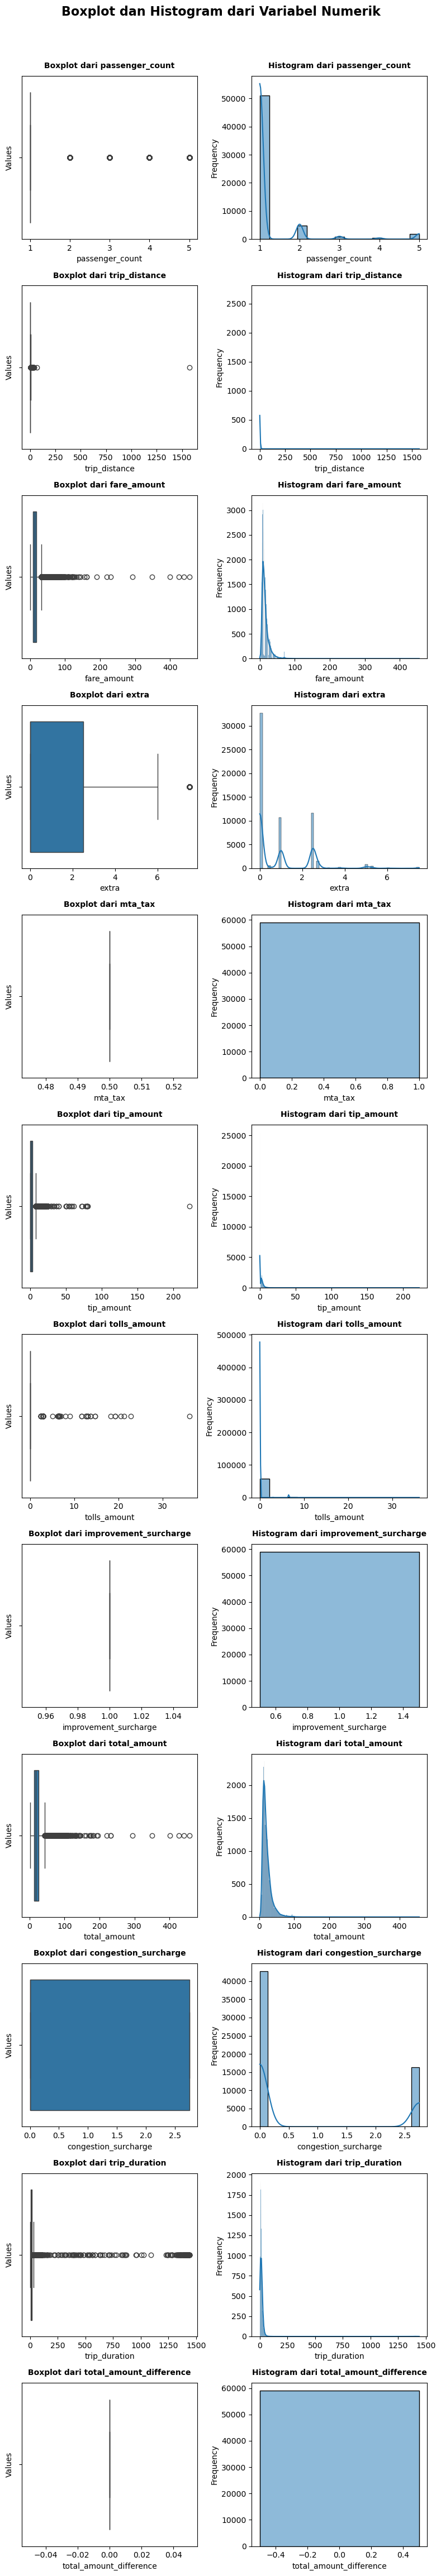

In [104]:
# Pilih hanya kolom numerik
numeric_columns = df.select_dtypes(include=['number']).columns

# Tentukan jumlah baris dan kolom
num_columns = len(numeric_columns)
num_rows = int(np.ceil(num_columns))  # Setiap kolom akan memiliki 1 baris (boxplot + histogram)

# Set ukuran gambar
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(8, 4 * num_rows))

axes = axes.flatten()

for i, column in enumerate(numeric_columns, 1):
    # Membuat boxplot di kolom pertama
    sns.boxplot(data=df, x=column, ax=axes[2*i-2])
    axes[2*i-2].set_title(f'Boxplot dari {column}', pad=10, fontweight='bold', fontsize=10)
    axes[2*i-2].set_xlabel(column)
    axes[2*i-2].set_ylabel('Values')
    
    # Membuat histogram di kolom kedua
    sns.histplot(df[column], kde=True, ax=axes[2*i-1])  # Histogram dengan KDE
    axes[2*i-1].set_title(f'Histogram dari {column}', pad=10, fontweight='bold', fontsize=10)
    axes[2*i-1].set_xlabel(column)
    axes[2*i-1].set_ylabel('Frequency')

# Menambahkan judul umum
plt.suptitle('Boxplot dan Histogram dari Variabel Numerik', fontsize=16, fontweight='bold')

# Atur layout
plt.tight_layout(rect=[0, 0.02, 1, 0.97])

# Menampilkan plot
plt.show()


Teridentifikasi adanya outlier pada beberapa kolom dalam dataset. Oleh karena itu, outlier-outlier tersebut akan ditinjau lebih lanjut untuk menentukan langkah penanganan yang tepat.

Dilakukan juga pengecekan distribusi data untuk kepentingan analisa selanjutnya.

In [107]:
numeric_df = df.select_dtypes(include=['number'])

for column in  numeric_df:
    stat,p = shapiro(df[column].dropna())
    alpha = 0.05
    if p > alpha:
        print(f"Kolom '{column}' terdistribusi normal (p-value: {p:.4f})")
    else:
        print(f"Kolom '{column}' tidak terdistribusi normal (p-value: {p:.4f})")

Kolom 'passenger_count' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'trip_distance' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'fare_amount' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'extra' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'mta_tax' terdistribusi normal (p-value: 1.0000)
Kolom 'tip_amount' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'tolls_amount' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'improvement_surcharge' terdistribusi normal (p-value: 1.0000)
Kolom 'total_amount' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'congestion_surcharge' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'trip_duration' tidak terdistribusi normal (p-value: 0.0000)
Kolom 'total_amount_difference' terdistribusi normal (p-value: 1.0000)


Dapat dilihat bahwa kolom-kolom tidak terdistribusi secara normal kecuali `mta_tax`, `improvement_surcharge`, dan `total_amount_difference`, hal tersebut dikarenakan value pada 3 kolom tersebut semuanya sama.

Untuk mengetahui tindakan yang tepat dilakukan terhadap outlier maka akan dilihat dari kolinearitasnya menggunakan spearman karena data-datanya terdistribusi secara tidak normal (kecuali `mta_tax` dan `improvement_surcharge` karena valuenya sama semua) terlebih dahulu.

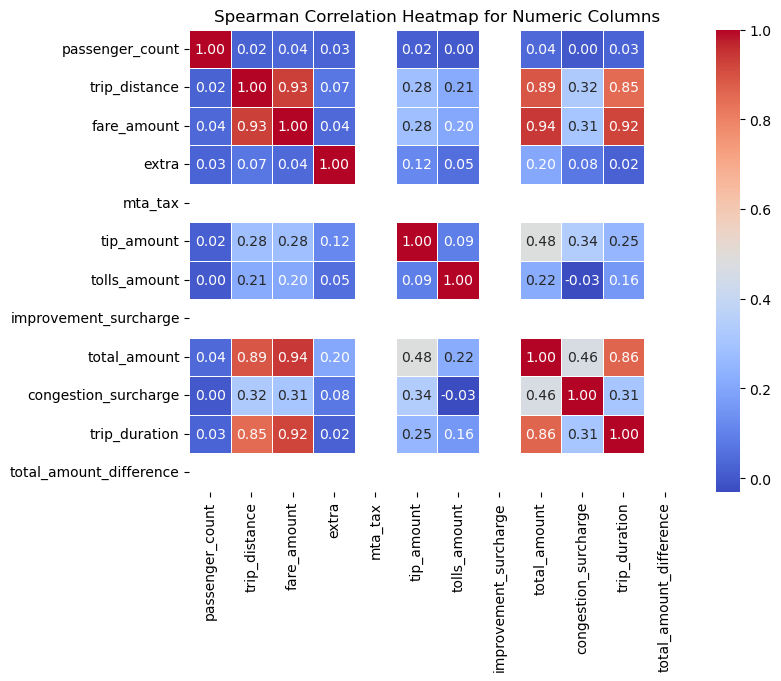

In [110]:
# Menghitung korelasi Spearman (lebih robust terhadap data tidak normal)
correlation_spearman = numeric_df.corr(method='spearman')

# Membuat heatmap untuk visualisasi korelasi Spearman
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_spearman, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Spearman Correlation Heatmap for Numeric Columns')
plt.show()


**Analisis Korelasi Heatmap Spearman Correlation**

**Korelasi Kuat Positif (>0.8)**
* Terdapat hubungan yang sangat kuat antara `fare amount` dan `trip distance` dengan nilai korelasi 0.93, mengindikasikan bahwa jarak perjalanan sangat mempengaruhi biaya perjalanan dasar
* `Total amount` dan `fare amount` memiliki korelasi 0.94, menunjukkan bahwa biaya perjalanan dasar adalah komponen utama dalam total biaya
* `Trip duration` memiliki korelasi kuat dengan `fare amount` (0.92) dan `trip distance` (0.85), mengindikasikan durasi perjalanan sangat berkaitan dengan jarak tempuh dan biaya
* `Total amount` berkorelasi kuat dengan `trip duration` (0.86), menandakan durasi perjalanan berkontribusi signifikan terhadap total biaya

**Korelasi Sedang (0.3-0.5)**
* `Tip amount` menunjukkan korelasi moderat dengan `total amount` (0.48), mengindikasikan bahwa besarnya tip memiliki hubungan sedang dengan total biaya perjalanan
* `Congestion surcharge` memiliki korelasi sedang dengan `total amount` (0.46), menunjukkan biaya kemacetan memiliki pengaruh moderat terhadap total biaya

**Korelasi Lemah (<0.3)**
* `Passenger count` menunjukkan korelasi yang sangat lemah dengan semua variabel (mayoritas <0.05), mengindikasikan jumlah penumpang tidak mempengaruhi variabel biaya secara signifikan
* `Extra charge` memiliki korelasi lemah dengan seluruh variabel, menandakan biaya tambahan beroperasi secara independen
* `Tolls amount` menunjukkan korelasi lemah dengan mayoritas variabel dalam dataset

**Temuan Penting**
* Biaya perjalanan (`fare amount`) sangat dipengaruhi oleh metrik perjalanan dasar yaitu jarak dan durasi
* Jumlah penumpang memiliki pengaruh minimal terhadap struktur biaya secara keseluruhan
* Biaya tol dan biaya tambahan (`extra`) beroperasi secara relatif independen dari variabel lainnya
* Total biaya paling kuat dipengaruhi oleh tiga faktor utama: biaya perjalanan dasar (`fare amount`), jarak (`trip distance`), dan durasi perjalanan (`trip duration`)

**Kesimpulan**
Analisis korelasi mengungkapkan bahwa sistem penetapan harga perjalanan taksi terutama didasarkan pada metrik perjalanan fundamental seperti jarak dan waktu, dibandingkan dengan faktor tambahan seperti jumlah penumpang atau biaya tol. Ini menunjukkan model bisnis yang mengutamakan efisiensi dan transparansi dalam penetapan harga perjalanan.

**Outlier dan Anomali Yang Akan Dibahas**

Berdasarkan hasil analisis visualisasi heatmap korelasi Spearman, maka outlier yang akan dibahas merupakan outlier `trip_distance` dan `tip_amount` karena kedua variabel ini menunjukkan pola korelasi yang signifikan dan unik. `Trip_distance` memiliki korelasi yang sangat kuat dengan komponen biaya utama seperti `fare_amount`, `total_amount`, dan `trip_duration`, sehingga outlier pada variabel ini akan sangat mempengaruhi akurasi perhitungan biaya perjalanan. Sedangkan `tip_amount` dipilih karena memiliki pola korelasi yang moderat hanya dengan `total_amount` dan korelasi lemah dengan variabel lainnya, yang mengindikasikan potensi anomali dalam perilaku pemberian tip atau kemungkinan adanya kesalahan input data.

### 3.6.1 Outlier dan Anomali `trip_distance`

Dalam bagian ini akan dilakukan penanganan pada anomali dan outlier `trip_distance`

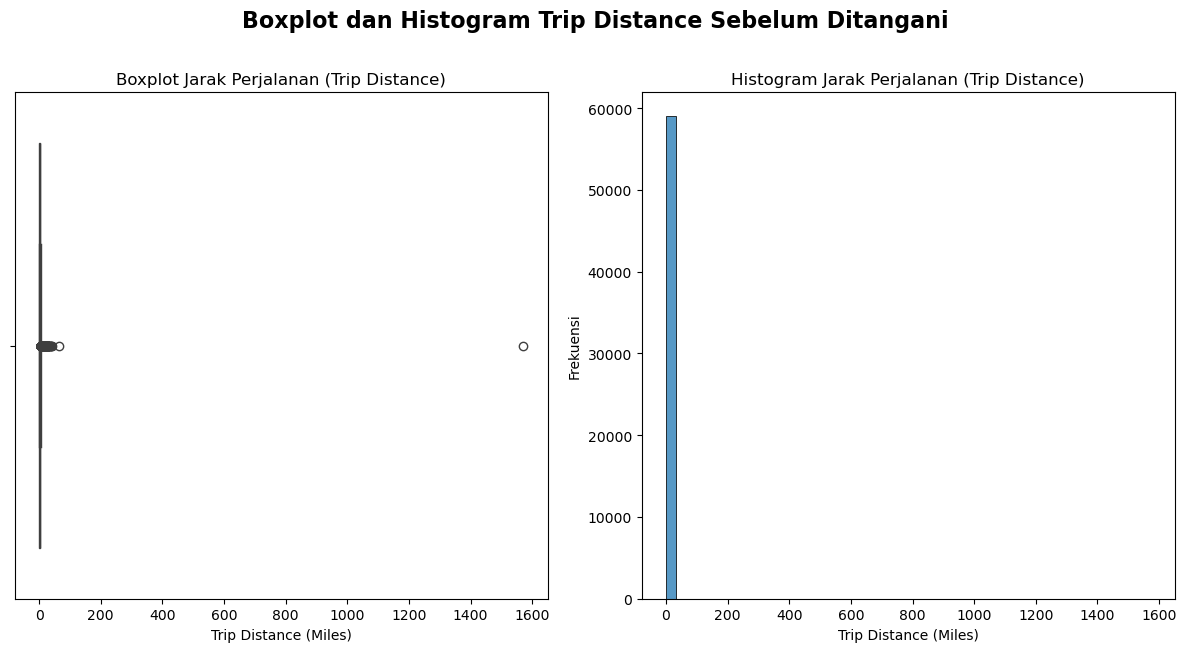

In [115]:
# Membuat plot untuk trip_distance
plt.figure(figsize=(12, 6))

# Menambahkan judul di tengah-tengah kedua plot tanpa menabrak
plt.figtext(0.5, 1.05, 'Boxplot dan Histogram Trip Distance Sebelum Ditangani', ha='center', fontsize=16, fontweight='bold')

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=df['trip_distance'])
plt.title('Boxplot Jarak Perjalanan (Trip Distance)')
plt.xlabel('Trip Distance (Miles)')

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(df['trip_distance'], bins=50)
plt.title('Histogram Jarak Perjalanan (Trip Distance)')
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Frekuensi')

# Menampilkan plot
plt.tight_layout()
plt.show()

Untuk menangani outliers yang ada pada `trip_distance` maka akan dilihat anomali dan outliernya terlebih dahulu.

In [117]:
# Menghitung kuartil pertama dan ketiga
Q1 = df['trip_distance'].quantile(0.25)
Q3 = df['trip_distance'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas atas dan bawah
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Menampilkan baris yang merupakan outlier atas
outliers_above = df[df['trip_distance'] > upper_bound].sort_values(by='trip_distance', ascending=False)

# Menampilkan baris yang merupakan outlier bawah
outliers_below = df[df['trip_distance'] < lower_bound].sort_values(by='trip_distance', ascending=True)

# Menampilkan DataFrame dengan outlier atas
print("Outliers atas:")
display(outliers_above)

# Menampilkan DataFrame dengan outlier bawah
print("Outliers bawah:")
display(outliers_below)


Outliers atas:


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,congestion_surcharge,PUBorough,PUZone,PUService_Zone,DOBorough,DOZone,DOService_Zone,trip_duration,trip_duration_formatted,total_amount_difference
33373,2,2023-01-17 18:40:38,2023-01-17 19:04:45,N,5.0,82,236,1,1571.97,29.97,...,2.75,Queens,Elmhurst,Boro Zone,Manhattan,Upper East Side North,Yellow Zone,24.116667,24:07,0.0
7322,2,2023-01-05 09:00:03,2023-01-05 15:18:38,N,5.0,134,134,1,66.18,15.00,...,2.75,Queens,Kew Gardens,Boro Zone,Queens,Kew Gardens,Boro Zone,378.583333,378:35,0.0
8072,2,2023-01-05 14:53:00,2023-01-05 16:19:20,N,1.0,130,1,1,41.74,114.00,...,0.00,Queens,Jamaica,Boro Zone,EWR,Newark Airport,EWR,86.333333,86:20,0.0
37830,2,2023-01-19 18:33:44,2023-01-19 19:38:57,N,1.0,130,1,1,38.60,140.20,...,0.00,Queens,Jamaica,Boro Zone,EWR,Newark Airport,EWR,65.216667,65:13,0.0
40942,2,2023-01-21 08:05:27,2023-01-21 09:00:47,N,1.0,219,1,1,38.24,140.20,...,0.00,Queens,Springfield Gardens South,Boro Zone,EWR,Newark Airport,EWR,55.333333,55:20,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43855,2,2023-01-22 18:16:10,2023-01-22 18:36:51,N,1.0,82,171,1,6.08,27.50,...,0.00,Queens,Elmhurst,Boro Zone,Queens,Murray Hill-Queens,Boro Zone,20.683333,20:41,0.0
33534,2,2023-01-17 19:47:06,2023-01-17 20:07:26,N,1.0,166,158,1,6.08,28.90,...,2.75,Manhattan,Morningside Heights,Boro Zone,Manhattan,Meatpacking/West Village West,Yellow Zone,20.333333,20:20,0.0
11711,2,2023-01-07 01:51:04,2023-01-07 02:12:00,N,1.0,255,188,1,6.08,28.20,...,0.00,Brooklyn,Williamsburg (North Side),Boro Zone,Brooklyn,Prospect-Lefferts Gardens,Boro Zone,20.933333,20:56,0.0
28667,2,2023-01-15 04:14:33,2023-01-15 04:34:24,N,1.0,36,79,5,6.08,27.50,...,2.75,Brooklyn,Bushwick North,Boro Zone,Manhattan,East Village,Yellow Zone,19.850000,19:51,0.0


Outliers bawah:


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,congestion_surcharge,PUBorough,PUZone,PUService_Zone,DOBorough,DOZone,DOService_Zone,trip_duration,trip_duration_formatted,total_amount_difference


**Menentukan perjalanan taxi terjauh di NYC**

Dalam menangani outlier, kita perlu terlebih dahulu menentukan jarak terjauh dan jarak terpendek perjalanan taksi di New York City (NYC). Jarak terjauh antar boroughs, berdasarkan data yang dikeluarkan oleh Walks (perusahaan tur), adalah 35 mil. Untuk memperhitungkan berbagai faktor lain seperti lika-liku jalan, kita menambahkan toleransi sebesar 50% dari jarak tersebut, yang dianggap sebagai penentuan toleransi yang konservatif. Penambahan toleransi ini dimaksudkan untuk lebih akurat mencerminkan kenyataan perjalanan taksi di jalanan kota yang sering kali berkelok-kelok dan tidak lurus.

Data diambil di: https://www.takewalks.com/blog/nyc-by-the-numbers#:~:text=The%20total%20area%20of%20the,Satellite%20view%20of%20NYC

In [119]:
# Jarak terjauh antar boroughs (miles)
max_distance = 35

# Menambahkan toleransi 50%
tolerance_factor = 0.5
longest_possible_distance = max_distance * (1 + tolerance_factor)

# Menampilkan hasil
print(f"Jarak terjauh yang diperhitungkan dengan toleransi 50% adalah: {longest_possible_distance} miles")


Jarak terjauh yang diperhitungkan dengan toleransi 50% adalah: 52.5 miles


Dari hasil yang telah diperoleh, terdeteksi adanya outlier atas pada kolom `trip_distance` dengan nilai yang sangat tinggi, yaitu 1571,97 miles. Angka ini jelas tidak wajar, mengingat durasi perjalanan yang tercatat hanya sebesar 24 menit 7 detik (berdasarkan kolom `trip_duration_formatted`). Jarak yang sangat besar ini tentu saja mustahil untuk ditempuh dalam waktu tersebut, karena jauh melampaui jarak terjauh yang telah ditentukan sebelumnya.

Selain itu, terdapat juga outlier lainnya pada `trip_distance` yang mencapai 66,18 miles, yang meskipun masih berada di luar batas jarak terjauh yang telah ditentukan, tetap menunjukkan keanehan. Hal ini disebabkan karena meskipun jaraknya melebihi batas yang wajar, baik `PUBorough` maupun `DOBorough` tercatat berada di borough yang sama, yaitu Queens. 

Oleh karena itu, kedua data outlier tersebut akan dihapus, dengan mempertimbangkan bahwa penghapusan outlier lebih aman dan efektif daripada imputasi, mengingat korelasi yang tinggi antar fitur. Dengan menghapus baris yang mengandung outlier, hubungan antar fitur dan integritas model tetap terjaga, tanpa mempengaruhi hasil analisis secara signifikan

In [121]:
# Drop baris dengan trip_distance di atas 52.5 miles
df.drop(df[df['trip_distance'] > 52.5].index, inplace=True)


In [122]:
len(df[df['trip_distance'] > 52.5])

0

**Menentukan perjalanan taxi terpendek di NYC**

Untuk menentukan jarak terendah dalam perjalanan taksi di New York City (NYC), diasumsikan bahwa perjalanan dengan jarak sangat pendek mungkin terjadi meskipun jarang, seperti penggunaan taksi sebagai tempat berlindung sementara dari cuaca buruk atau faktor lain seperti malas berjalan kaki. Namun, untuk memverifikasi apakah data dengan `trip_distance` yang rendah tersebut layak, perlu diperhatikan beberapa aspek, seperti apakah ada `tolls_amount` atau apakah `PUZone` dan `DOZone berbed`a. Secara umum, perjalanan dengan jarak sangat pendek cenderung tidak melibatkan tol atau hanya melibatkan perjalanan antar lokasi dalam satu area yang sama.

Sebagai langkah awal, akan dilakukan analisis dengan memeriksa data yang memiliki `trip_distance` di bawah panjang blok standar di Manhattan, yang diperkirakan sekitar 0,17 mil atau 900 kaki berdasarkan domain knowledge dan generalisasi informasi yang tersedia. Jika jarak tempuh taksi lebih pendek dari itu, maka data tersebut akan dianggap sebagai outlier kecuali jika terdapat `tolls_amount` atau jika `PUZone` dan `DOZone` menunjukkan lokasi yang berbeda. Di NYC, Manhattan dipilih sebagai acuan karena kepadatan bangunannya yang tinggi, dengan jalan-jalan yang saling berdempetan, sehingga perjalanan jarak pendek lebih sering terjadi di daerah ini.

In [124]:
# Menyeleksi data yang memiliki trip_distance < 0.17 dan memenuhi salah satu dari kondisi tolls_amount > 0 atau PUZone != DOZone
filtered_trip_distance_data = df[(df['trip_distance'] < 0.17) & 
                   ((df['tolls_amount'] > 0) | (df['PUZone'] != df['DOZone']))]

# Menghitung jumlah data yang memenuhi kriteria
trip_distance_count_filtered = filtered_trip_distance_data.shape[0]

# Menghitung persentase data yang memenuhi kriteria
percentage_filtered_trip_distance = (trip_distance_count_filtered / df.shape[0]) * 100

# Menampilkan hasil
print(f"Jumlah data yang memiliki trip_distance < 0.17 dan tolls_amount > 0 atau PUZone ≠ DOZone: {trip_distance_count_filtered}")
print(f"Persentase dari data: {percentage_filtered_trip_distance:.2f}%")


Jumlah data yang memiliki trip_distance < 0.17 dan tolls_amount > 0 atau PUZone ≠ DOZone: 72
Persentase dari data: 0.12%


Dari hasil analisis, ditemukan adanya anomali sebanyak 72  data dengan persentase hanya sebesar 0.12%. Karena jumlah data yang terdeteksi sebagai anomali ini sangat sedikit, maka akan lebih baik jika data tersebut dihapus (drop) daripada mempengaruhi analisis lebih lanjut. Penghapusan data ini diharapkan tidak memengaruhi hasil analisis secara signifikan, mengingat persentase yang sangat kecil dari total data.

In [126]:
# Menghapus data yang memenuhi kriteria dari DataFrame asli
df = df.drop(filtered_trip_distance_data.index)

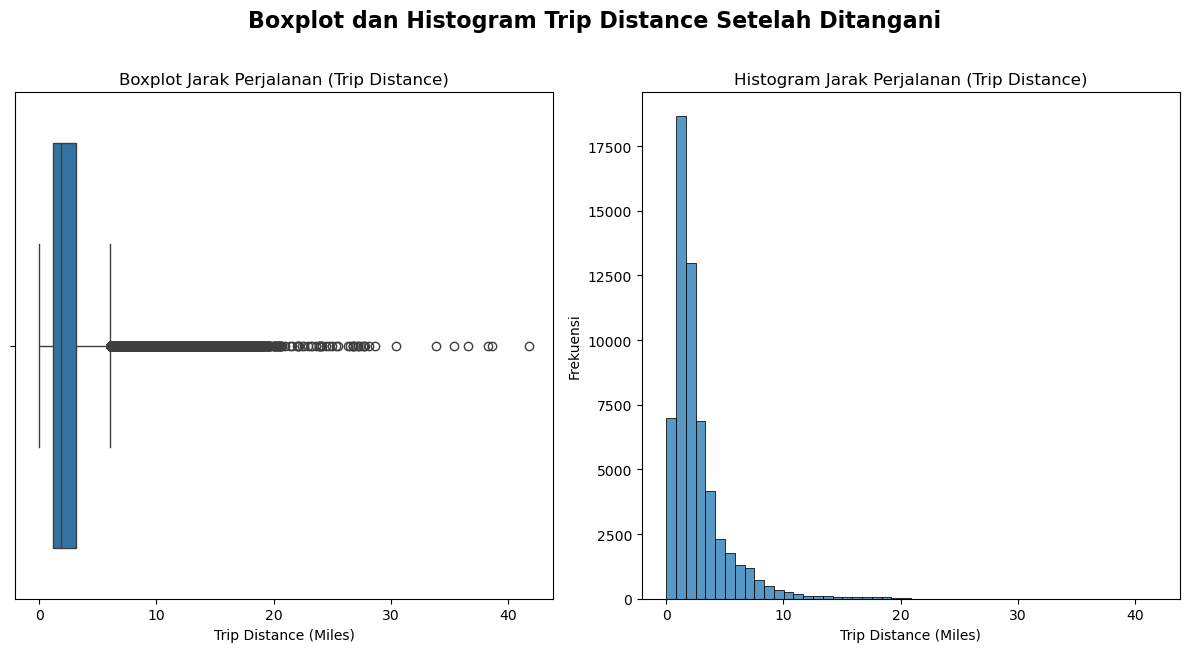

In [127]:
# Membuat plot untuk trip_distance
plt.figure(figsize=(12, 6))

# Menambahkan judul di tengah-tengah kedua plot tanpa menabrak
plt.figtext(0.5, 1.05, 'Boxplot dan Histogram Trip Distance Setelah Ditangani', ha='center', fontsize=16, fontweight='bold')

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=df['trip_distance'])
plt.title('Boxplot Jarak Perjalanan (Trip Distance)')
plt.xlabel('Trip Distance (Miles)')

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(df['trip_distance'], bins=50)
plt.title('Histogram Jarak Perjalanan (Trip Distance)')
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Frekuensi')

# Menampilkan plot
plt.tight_layout()
plt.show()

### 3.6.2 Outlier dan Anomali `tip_amount`

Dalam bagian ini akan dilakukan penanganan pada anomali dan outlier `tip_amount`

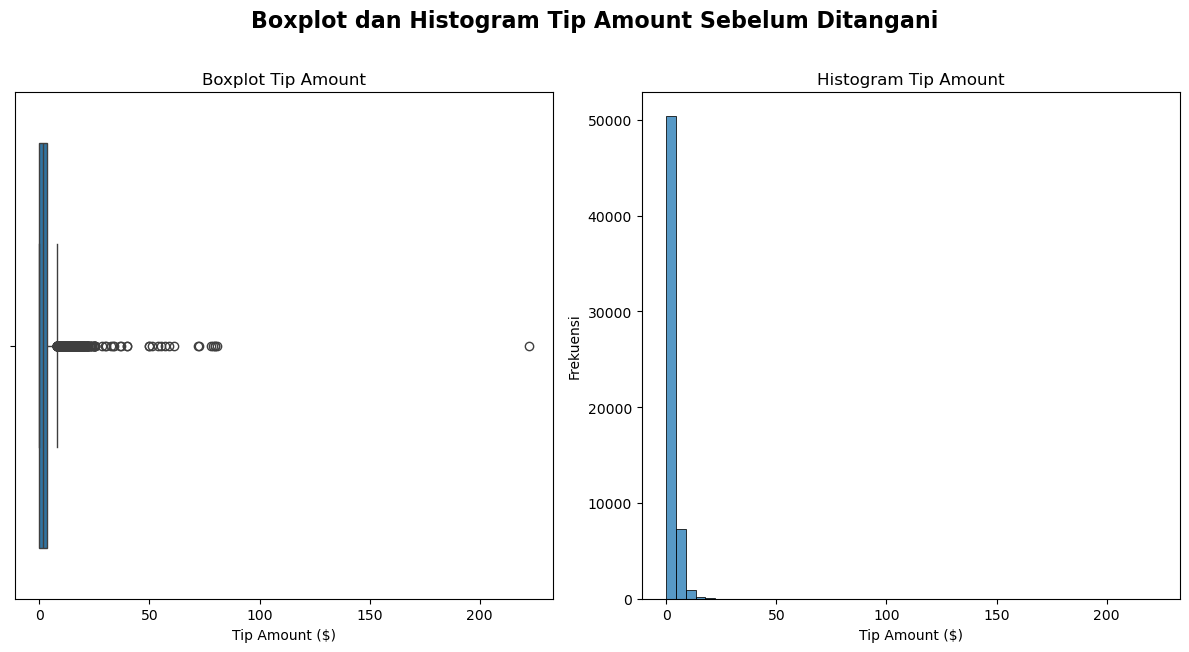

In [130]:
# Membuat plot untuk tip_amount
plt.figure(figsize=(12, 6))

# Menambahkan judul di tengah-tengah kedua plot tanpa menabrak
plt.figtext(0.5, 1.05, 'Boxplot dan Histogram Tip Amount Sebelum Ditangani', ha='center', fontsize=16, fontweight='bold')

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=df['tip_amount'])
plt.title('Boxplot Tip Amount')
plt.xlabel('Tip Amount ($)')

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(df['tip_amount'], bins=50)
plt.title('Histogram Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frekuensi')

# Menampilkan plot
plt.tight_layout()
plt.show()


Untuk menangani outliers yang ada pada `tip_amount` maka akan dilihat anomali dan outliernya terlebih dahulu.

Berdasarkan pengetahuan domain, dalam kondisi normal, pemberian tip untuk layanan taksi di New York City umumnya berkisar sekitar 30% dari harga jasa taksi. Oleh karena itu, akan dilakukan analisis untuk mengevaluasi jumlah `tip_amount` yang melebihi persentase tersebut, guna memahami apakah ada penyimpangan yang signifikan dalam data."

In [133]:
# Menentukan 30% dari adjusted_total_amount dengan membuat kolom baru
df['tip_percentage'] = df['tip_amount'] / df['total_amount'] * 100

# Menyaring data yang memiliki tip_amount lebih dari 30% dari adjusted_total_amount
filtered_tip_data = df[df['tip_percentage'] > 30]

# Menghitung jumlah data yang memenuhi kriteria
tip_count_filtered = filtered_tip_data.shape[0]

# Menghitung persentase data yang memenuhi kriteria
percentage_filtered_tip = (tip_count_filtered / df.shape[0]) * 100

# Menampilkan hasil
print(f"Jumlah data yang memiliki tip_amount lebih dari 30% dari adjusted_total_amount: {tip_count_filtered}")
print(f"Persentase dari data: {percentage_filtered_tip:.2f}%")


Jumlah data yang memiliki tip_amount lebih dari 30% dari adjusted_total_amount: 248
Persentase dari data: 0.42%


Dari hasil analisis, ditemukan adanya anomali sebanyak 248 baris data dengan persentase sebesar 0.42%. Karena jumlah data yang terdeteksi sebagai anomali ini relatif kecil, maka akan lebih baik jika data tersebut dihapus (drop) daripada mempengaruhi analisis lebih lanjut. Penghapusan data ini diharapkan tidak memengaruhi hasil analisis secara signifikan, mengingat persentase yang sangat kecil dari total data.

In [135]:
# Menghapus data yang memiliki tip_percentage lebih dari 30%
df = df.drop(filtered_tip_data.index)

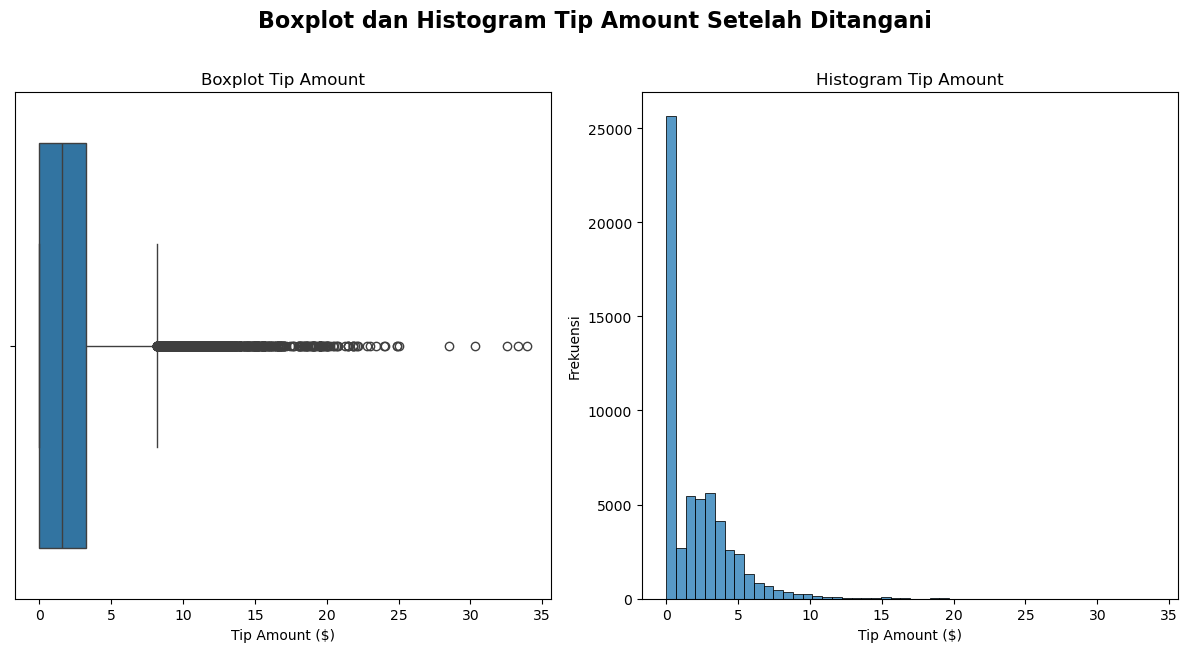

In [136]:
# Membuat plot untuk tip_amount
plt.figure(figsize=(12, 6))

# Menambahkan judul di tengah-tengah kedua plot tanpa menabrak
plt.figtext(0.5, 1.05, 'Boxplot dan Histogram Tip Amount Setelah Ditangani', ha='center', fontsize=16, fontweight='bold')

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=df['tip_amount'])
plt.title('Boxplot Tip Amount')
plt.xlabel('Tip Amount ($)')

# Histogram
plt.subplot(1, 2, 2)
sns.histplot(df['tip_amount'], bins=50)
plt.title('Histogram Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frekuensi')

# Menampilkan plot
plt.tight_layout()
plt.show()


## 2.8 Analysis

Setelah Dilakukan data Cleaning, maka akan dilakukan Analysis sesuai dengan Problem Statement yang telah ditentukan. Akan dimulai dengan Problem Statement pertama terlebih dahulu.

### 2.8.1 **Menentukan Jam Sibuk Bagi Tiap Borough NYC**

Analisis ini bertujuan untuk memberikan rekomendasi penempatan armada taksi yang efisien berdasarkan jam sibuk di berbagai borough di New York City. Proses dimulai dengan menghitung jumlah trip per jam untuk setiap borough, serta mengidentifikasi jam sibuk utama (peak hour) berdasarkan median frekuensi trip. Selain itu, jam-jam tambahan yang memiliki frekuensi trip mendekati jam sibuk utama juga dipertimbangkan untuk menentukan rentang waktu yang optimal.

Rekomendasi penempatan armada dihitung dengan menggunakan ambang batas tertentu (threshold) untuk memilih jam sibuk tambahan, berdasarkan frekuensi trip yang tercatat selama weekday dan weekend. Dengan demikian, hasilnya memberikan informasi mengenai waktu optimal bagi setiap borough untuk menempatkan armada taksi, baik pada jam sibuk utama maupun tambahan, guna meningkatkan efisiensi operasional.

In [141]:
# 1. Group by Tanggal dan Jam untuk menghitung jumlah trip per jam
df['pickup_date'] = df['lpep_pickup_datetime'].dt.date
df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
df['weekday'] = df['lpep_pickup_datetime'].dt.weekday  # Tambahkan kolom untuk mengetahui hari dalam seminggu
df['day_type'] = df['weekday'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')  # Klasifikasi weekday/weekend

hourly_trip_counts = df.groupby(['pickup_date', 'pickup_hour', 'day_type']).size().reset_index(name='trip_count')


In [142]:
# 2. Uji Normalitas untuk tiap jam dan tipe hari
normality_results = []
for hour in range(24):
    for day_type in ['Weekday', 'Weekend']:
        hourly_data = hourly_trip_counts[(hourly_trip_counts['pickup_hour'] == hour) & 
                                         (hourly_trip_counts['day_type'] == day_type)]['trip_count']
        if len(hourly_data) >= 3:  # Shapiro membutuhkan minimal 3 sampel
            stat, p_value = shapiro(hourly_data)
            status = 'Normal' if p_value >= 0.05 else 'Tidak Normal'
            
            normality_results.append({
                'hour': hour,
                'day_type': day_type,
                'stat': stat,
                'p_value': p_value,
                'status': status
            })

normality_df = pd.DataFrame(normality_results)

normality_df

,hour,day_type,stat,p_value,status
0,0,Weekday,0.964552,5.863209e-01,Normal
1,0,Weekend,0.894237,2.204570e-01,Normal
2,1,Weekday,0.869499,7.661804e-03,Tidak Normal
3,1,Weekend,0.893235,2.153375e-01,Normal
4,2,Weekday,0.954564,3.877157e-01,Normal
5,2,Weekend,0.853005,8.041076e-02,Normal
6,3,Weekday,0.849561,3.334515e-03,Tidak Normal
7,3,Weekend,0.930965,4.905895e-01,Normal
8,4,Weekday,0.854747,4.123424e-03,Tidak Normal
9,4,Weekend,0.964197,8.410624e-01,Normal


Dapat dilihat bahwa sebagian besar data menunjukkan status normal. Namun, ada juga data yang tidak terdistribusi normal. Oleh karena itu, untuk analisis ini, penggunaan median tetap lebih aman, karena terdapat beberapa jam yang tidak mengikuti distribusi normal. Penggunaan median juga lebih stabil dalam menghindari pengaruh nilai ekstrim atau outlier yang dapat mempengaruhi hasil analisis, dikarenakan secara umum, median adalah pilihan yang lebih bijak dalam menghadapi data yang tidak sepenuhnya normal, meskipun sebagian besar jam memiliki distribusi normal.

In [144]:
# 3. Hitung median atau rata-rata frekuensi per jam berdasarkan hasil uji normalitas
median_frequency_per_hour = []
for hour in range(24):
    for day_type in ['Weekday', 'Weekend']:
        hourly_data = hourly_trip_counts[(hourly_trip_counts['pickup_hour'] == hour) & 
                                         (hourly_trip_counts['day_type'] == day_type)]['trip_count']
        
        # Cek hasil uji normalitas untuk jam dan tipe hari ini
        normality_status = normality_df[(normality_df['hour'] == hour) & 
                                        (normality_df['day_type'] == day_type)]['status'].values[0]
        
        # Tentukan penghitungan berdasarkan status normalitas
        if normality_status == 'Normal':
            freq_value = hourly_data.mean()  # Gunakan rata-rata jika normal
        else:
            freq_value = hourly_data.median()  # Gunakan median jika tidak normal
        
        median_frequency_per_hour.append({
            'hour': hour,
            'day_type': day_type,
            'frequency': freq_value
        })

median_frequency_per_hour_df = pd.DataFrame(median_frequency_per_hour)

# Menampilkan hasil penghitungan frekuensi
display("Frekuensi per Jam berdasarkan Normalitas:\n", median_frequency_per_hour_df)


'Frekuensi per Jam berdasarkan Normalitas:\n'

,hour,day_type,frequency
0,0,Weekday,22.818182
1,0,Weekend,50.000000
2,1,Weekday,13.000000
3,1,Weekend,47.555556
4,2,Weekday,9.090909
5,2,Weekend,35.222222
6,3,Weekday,9.000000
7,3,Weekend,30.555556
8,4,Weekday,5.500000
9,4,Weekend,23.000000


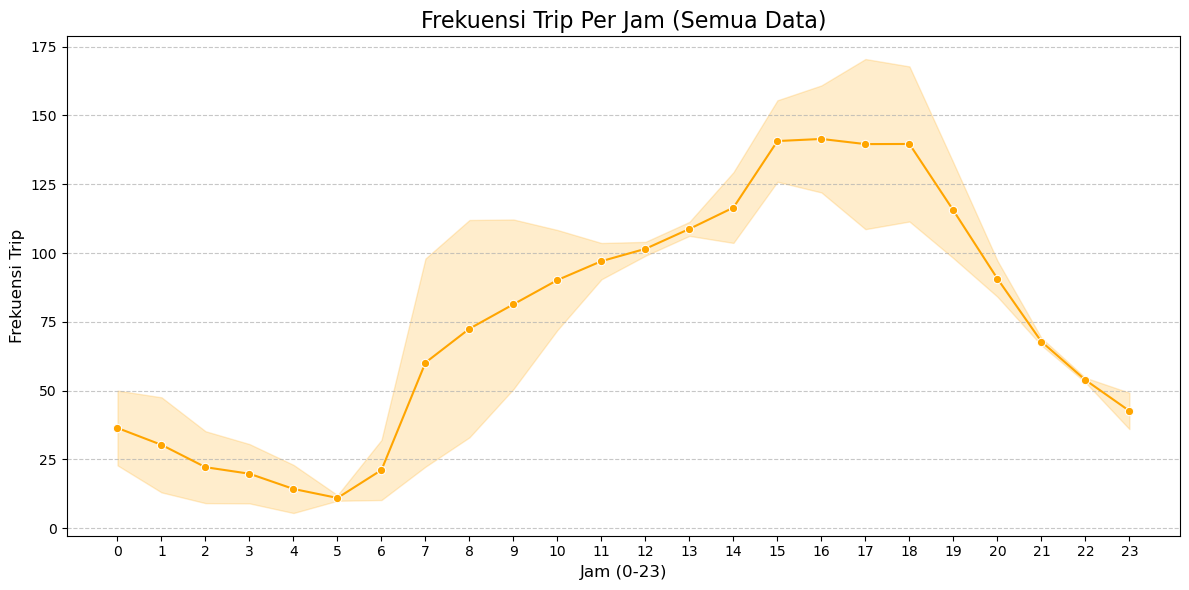

In [145]:
#4.  Visualisasi line plot untuk semua data (Global)
plt.figure(figsize=(12, 6))
sns.lineplot(data=median_frequency_per_hour_df, x='hour', y='frequency', marker='o', color='orange')
plt.title("Frekuensi Trip Per Jam (Semua Data)", fontsize=16)
plt.xlabel("Jam (0-23)", fontsize=12)
plt.ylabel("Frekuensi Trip", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

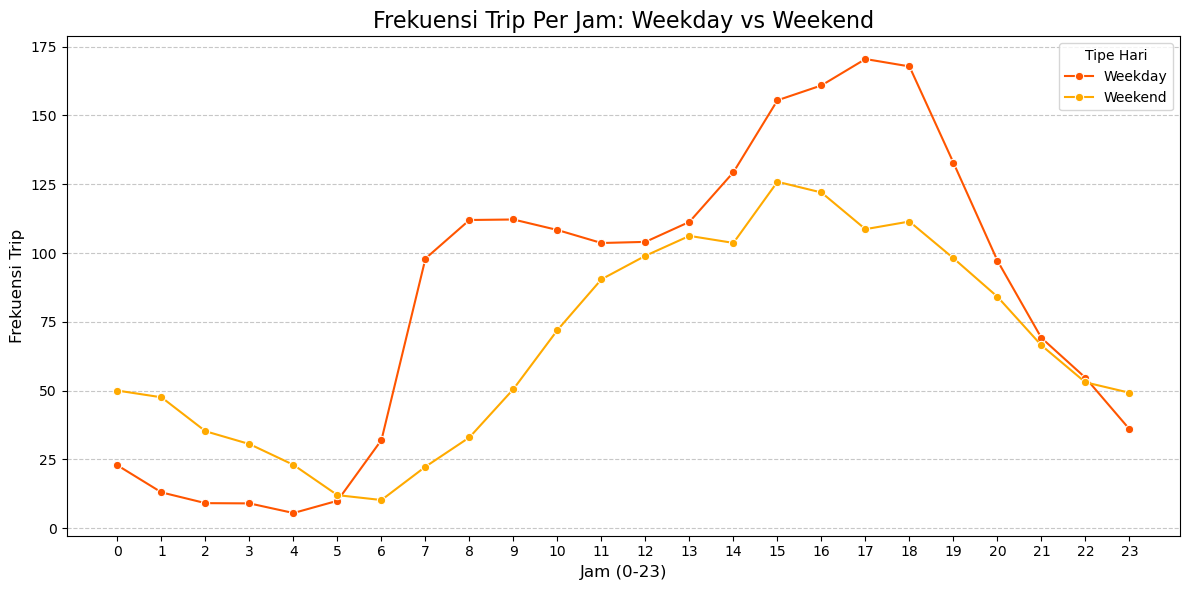

In [146]:
# 5. Visualisasi line plot untuk Weekday vs Weekend
plt.figure(figsize=(12, 6))
sns.lineplot(data=median_frequency_per_hour_df, x='hour', y='frequency', hue='day_type', marker='o', palette='autumn')
plt.title("Frekuensi Trip Per Jam: Weekday vs Weekend", fontsize=16)
plt.xlabel("Jam (0-23)", fontsize=12)
plt.ylabel("Frekuensi Trip", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Tipe Hari", loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
# 6. Visualisasi per borough berdasarkan Weekday dan Weekend
for borough in df['PUBorough'].unique():
    borough_data = df[df['PUBorough'] == borough]
    hourly_trip_counts_borough = borough_data.groupby(['pickup_date', 'pickup_hour', 'day_type']).size().reset_index(name='trip_count')
    median_frequency_per_hour_borough = hourly_trip_counts_borough.groupby(['day_type', 'pickup_hour'])['trip_count'].median().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=median_frequency_per_hour_borough, x='pickup_hour', y='trip_count', hue='day_type', marker='o', palette='autumn')
    plt.title(f"Frekuensi Trip Per Jam di {borough}: Weekday vs Weekend", fontsize=16)
    plt.xlabel("Jam (0-23)", fontsize=12)
    plt.ylabel("Frekuensi Trip", fontsize=12)
    plt.xticks(range(0, 24))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Tipe Hari", loc="upper right")
    plt.tight_layout()
    plt.show()


In [ ]:
# Ambang batas untuk memilih jam sibuk tambahan
threshold_percentage = 0.8

# List untuk menyimpan rekomendasi dengan rentang waktu dan jumlah armada
busy_hour_time_ranges = []

# Loop untuk tiap borough
for borough in df['PUBorough'].unique():
    borough_data = df[df['PUBorough'] == borough]
    hourly_trip_counts_borough = borough_data.groupby(['pickup_date', 'pickup_hour', 'day_type']).size().reset_index(name='trip_count')
    median_frequency_per_hour_borough = hourly_trip_counts_borough.groupby(['day_type', 'pickup_hour'])['trip_count'].median().reset_index()

    # Loop untuk tiap tipe hari (Weekday/Weekend)
    for day_type in ['Weekday', 'Weekend']:
        day_type_data = median_frequency_per_hour_borough[median_frequency_per_hour_borough['day_type'] == day_type]
        
        # Identifikasi jam sibuk utama
        busiest_hour_row = day_type_data.loc[day_type_data['trip_count'].idxmax()]
        busiest_hour = int(busiest_hour_row['pickup_hour'])
        busiest_median_trip = busiest_hour_row['trip_count']
        
        # Tambahkan jam tetangga dengan threshold
        relevant_hours = day_type_data[
            day_type_data['trip_count'] >= threshold_percentage * busiest_median_trip
        ]['pickup_hour'].tolist()
        relevant_hours.sort()

        # Format rentang waktu
        if len(relevant_hours) == 1:
            time_range = f"{relevant_hours[0]:02}:00"
        else:
            time_range = f"{relevant_hours[0]:02}:00-{relevant_hours[-1]+1:02}:00"
        
        # Simpan informasi rentang waktu
        busy_hour_time_ranges.append({
            'borough': borough,
            'day_type': day_type,
            'busiest_time_range': time_range
        })
        
# Membuat DataFrame dari busy_hour_time_ranges
busy_hour_time_ranges_df = pd.DataFrame(busy_hour_time_ranges)

busy_hour_time_ranges_df


**Insight:**

Berdasarkan data yang tersedia, masing-masing borough memiliki waktu sibuk yang berbeda pada hari kerja (Weekday) dan akhir pekan (Weekend). Berikut adalah beberapa poin utama:

- **Manhattan** memiliki waktu sibuk pada **Weekday** antara **08:00-19:00** dan pada **Weekend** antara **11:00-19:00**, menunjukkan bahwa Manhattan cenderung memiliki waktu sibuk yang lebih panjang pada hari kerja.
- **Brooklyn** memiliki waktu sibuk yang konsisten pada **Weekday** dan **Weekend**, yaitu antara **15:00-21:00**, yang menunjukkan pola waktu sibuk yang lebih terpusat pada sore hingga malam hari.
- **Queens** memiliki waktu sibuk pada **Weekday** antara **17:00-19:00** dan pada **Weekend** antara **15:00-20:00**, yang menunjukkan sedikit pergeseran waktu sibuk ke sore hari pada akhir pekan.
- **Bronx** menunjukkan waktu sibuk yang lebih panjang pada **Weekend**, yaitu antara **07:00-21:00**, sedangkan pada **Weekday**, waktu sibuk adalah antara **10:00-19:00**, yang lebih terkonsentrasi di jam kerja.
- **Staten Island** memiliki waktu sibuk yang relatif lebih pendek pada **Weekend**, hanya antara **03:00** dan **14:00-19:00** pada **Weekday**, yang menunjukkan waktu sibuk yang lebih terbatas dibandingkan borough lainnya.

Dapat dilihat setiap borough memiliki karakteristik waktu sibuk yang unik, dengan Manhattan dan Brooklyn memiliki waktu sibuk yang lebih panjang, sementara borough lain seperti Staten Island dan Bronx memiliki waktu sibuk yang lebih terbatas atau terfokus pada jam tertentu.


### 2.8.2 **Optimasi Penempatan Armada Taksi Berdasarkan Jam Sibuk di NYC**

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='PUBorough', palette='YlOrRd', order=df['PUBorough'].value_counts().index)
plt.title('Distribusi Jumlah Trip per Borough', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Jumlah Trip', fontsize=12)
plt.xticks(rotation=45)

# Menambahkan anotasi jumlah trip dengan format berbeda
for p in ax.patches:
    height = p.get_height()
    borough = p.get_x() + p.get_width() / 2  # Mendapatkan posisi tengah batang
    # Cek apakah nilai trip lebih dari atau sama dengan 1000
    if height >= 1000:
        ax.annotate(f'{height / 1000:.1f}k', 
                    (borough, height),  # Menempatkan teks di atas batang
                    ha='center', va='bottom', 
                    fontsize=12, color='black')
    else:
        ax.annotate(f'{height:.0f}', 
                    (borough, height),  # Menempatkan teks di atas batang
                    ha='center', va='bottom', 
                    fontsize=12, color='black')

# Format sumbu y dalam ribuan
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x / 1000:.1f}k' if x >= 1000 else f'{x:.0f}'))

plt.tight_layout()
plt.show()

# Hitung jumlah trip per borough
trip_counts_per_borough = df['PUBorough'].value_counts().reset_index()
trip_counts_per_borough.columns = ['Borough', 'Trip Count']

# Menampilkan DataFrame
trip_counts_per_borough


**Insight:**

Dari hasil olahan yang telah dilakukan, didapat informasi berupa:

- Manhattan memiliki jumlah trip terbanyak dengan 35.448 perjalanan.
- Queens memiliki jumlah trip 15.577 perjalanan.
- Brooklyn memiliki jumlah trip  7.100 perjalanan.
- Bronx memiliki jumlah trip 549 perjalanan.
- Staten Island hanya memiliki jumlah trip 7 perjalanan.

In [ ]:
# List untuk menyimpan estimasi jumlah trip
trip_count_estimations = []

# Loop untuk tiap borough
for borough in df['PUBorough'].unique():
    borough_data = df[df['PUBorough'] == borough]
    hourly_trip_counts_borough = borough_data.groupby(['pickup_date', 'pickup_hour', 'day_type']).size().reset_index(name='trip_count')
    median_frequency_per_hour_borough = hourly_trip_counts_borough.groupby(['day_type', 'pickup_hour'])['trip_count'].median().reset_index()

    # Loop untuk tiap tipe hari (Weekday/Weekend)
    for day_type in ['Weekday', 'Weekend']:
        day_type_data = median_frequency_per_hour_borough[median_frequency_per_hour_borough['day_type'] == day_type]
        
        # Identifikasi jam sibuk utama
        busiest_hour_row = day_type_data.loc[day_type_data['trip_count'].idxmax()]
        busiest_hour = int(busiest_hour_row['pickup_hour'])
        busiest_median_trip = busiest_hour_row['trip_count']
        
        # Tambahkan jam tetangga dengan threshold
        relevant_hours = day_type_data[
            day_type_data['trip_count'] >= threshold_percentage * busiest_median_trip
        ]['pickup_hour'].tolist()
        relevant_hours.sort()

        # Format rentang waktu
        if len(relevant_hours) == 1:
            time_range = f"{relevant_hours[0]:02}:00"
        else:
            time_range = f"{relevant_hours[0]:02}:00-{relevant_hours[-1]+1:02}:00"
        
        # 1. Menghitung total trip count dalam rentang waktu sibuk
        total_trip_count_in_range = day_type_data[day_type_data['pickup_hour'].isin(relevant_hours)]['trip_count'].sum()

        # Menyimpan estimasi jumlah trip
        trip_count_estimations.append({
            'borough': borough,
            'day_type': day_type,
            'busiest_time_range': time_range,
            'expected_trip_count': total_trip_count_in_range,  # Total trip count dalam rentang waktu
        })

# Membuat DataFrame dari estimasi jumlah trip
trip_count_estimations_df = pd.DataFrame(trip_count_estimations)

# Membulatkan expected_trip_count menggunakan round()
trip_count_estimations_df['expected_trip_count'] = trip_count_estimations_df['expected_trip_count'].round()

# Membulatkan expected_trip_count dan menghapus koma
trip_count_estimations_df['expected_trip_count'] = trip_count_estimations_df['expected_trip_count'].round().astype(int)

# Menampilkan DataFrame hasil
trip_count_estimations_df


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengurutkan trip_count_estimations_df berdasarkan expected_trip_count secara menurun
borough_trip_estimations_sorted = trip_count_estimations_df.sort_values('expected_trip_count', ascending=False)

# Membuat visualisasi distribusi expected_trip_count per borough di trip_count_estimations_df
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=borough_trip_estimations_sorted, x='borough', y='expected_trip_count', hue='day_type', palette='Wistia_r', ci=None)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Estimasi Jumlah Trip per Borough (Weekday vs Weekend)', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Jumlah Trip', fontsize=12)
plt.xticks(rotation=45)

# Menambahkan anotasi jumlah trip di atas batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0f}', 
                (p.get_x() + p.get_width() / 2, height),  # Menempatkan teks di atas batang
                ha='center', va='bottom', 
                fontsize=12, color='black')

# Menampilkan plot
plt.tight_layout()
plt.show()


In [ ]:
# Tentukan persentase tambahan armada
additional_armada_percentage = 0.1

**Alasan Menggunakan 10% sebagai Tambahan Armada%**

Pemilihan persentase tambahan armada sebesar 10% lebih didasarkan pada keseimbangan antara efisiensi operasional dan antisipasi lonjakan permintaan. Berikut beberapa alasan kenapa 10% lebih tepat dibandingkan lebih tinggi:

1. **Efisiensi Biaya:** Penambahan armada 10% cukup untuk mengatasi lonjakan permintaan tanpa meningkatkan biaya yang terlalu signifikan. Penambahan armada lebih dari 10% (seperti 20%) dapat mengakibatkan peningkatan biaya operasional yang tidak proporsional dengan peningkatan permintaan.

2. **Penghindaran Pemborosan:** Menambah armada lebih dari 10% berisiko memiliki armada yang tidak terpakai pada jam-jam tidak sibuk. Ini bisa menyebabkan pemborosan sumber daya, karena armada tambahan tidak akan optimal digunakan pada waktu yang tidak padat.

3. **Keseimbangan antara Responsivitas dan Biaya:** 10% dirasa cukup untuk memastikan ketersediaan armada yang cukup pada jam sibuk, tanpa berisiko membebani perusahaan dengan armada yang lebih banyak dari yang diperlukan.

Dengan demikian, 10% adalah angka yang cukup konservatif untuk menjaga keseimbangan antara kesiapan menghadapi lonjakan permintaan dan menjaga pengelolaan biaya yang efisien.


In [ ]:
# Membuat DataFrame baru untuk estimasi jumlah trip dan armada
trip_armada_estimations_df = trip_count_estimations_df.copy()

# Menambahkan required_minimum_armada berdasarkan expected_trip_count dan tambahan 10% dari jumlah trip
trip_armada_estimations_df['required_minimum_armada'] = (trip_armada_estimations_df['expected_trip_count'] * (1 + additional_armada_percentage)).astype(int)

# Menampilkan DataFrame hasil
trip_armada_estimations_df


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat visualisasi required_minimum_armada per borough di trip_armada_estimations_df
plt.figure(figsize=(12, 6))

# Membuat barplot berdasarkan required_minimum_armada dan mengurutkannya secara descending
ax = sns.barplot(data=trip_armada_estimations_df.sort_values(by='required_minimum_armada', ascending=False), 
                 x='borough', y='required_minimum_armada', hue='day_type', palette='viridis')

# Menambahkan judul dan label sumbu
plt.title('Distribusi Armada Minimum Diperlukan per Borough', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Armada Minimum Diperlukan', fontsize=12)
plt.xticks(rotation=45)

# Menambahkan anotasi jumlah armada di atas batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0f}', 
                (p.get_x() + p.get_width() / 2, height),  # Menempatkan teks di atas batang
                ha='center', va='bottom', 
                fontsize=12, color='black')

# Menampilkan plot
plt.tight_layout()
plt.show()

Ringkasan Analisis Armada Minimum Diperlukan per Borough

1. **Manhattan**
   - Weekday: 08:00-19:00, 760 trips, 836 armada
   - Weekend: 11:00-19:00, 498 trips, 547 armada
   - Manhattan membutuhkan armada terbanyak.

2. **Brooklyn**
   - Weekday: 15:00-21:00, 88 trips, 96 armada
   - Weekend: 15:00-21:00, 78 trips, 85 armada
   - Brooklyn stabil di weekday dan weekend.

3. **Queens**
   - Weekday: 17:00-19:00, 100 trips, 110 armada
   - Weekend: 15:00-20:00, 172 trips, 189 armada
   - Queens memiliki permintaan lebih tinggi pada weekend.

4. **Bronx**
   - Weekday: 10:00-19:00, 8 trips, 8 armada
   - Weekend: 07:00-21:00, 8 trips, 8 armada
   - Staten Island memiliki permintaan yang rendah.

5. **Staten Island**
   - Weekday: 14:00-19:00, 4 trips, 4 armada
   - Weekend: 03:00, 1 trip, 1 armada
   - Staten Island memiliki permintaan paling rendah.


### 2.8.3 **Mengidentifikasi Potensi Pendapatan Berdasarkan Proporsi Jam Sibuk di Setiap Borough**

In [ ]:
from scipy.stats import shapiro

# 1. Uji Normalitas Kolom `fare_amount` Per Borough
normality_results = []
for borough, data in df.groupby('PUBorough'):
    fare_amounts = data['fare_amount']
    if len(fare_amounts) >= 3:  # Shapiro-Wilk membutuhkan minimal 3 data
        stat, p_value = shapiro(fare_amounts)
        status = 'Normal' if p_value >= 0.05 else 'Tidak Normal'
        normality_results.append({
            'borough': borough,
            'stat': stat,
            'p_value': p_value,
            'status': status
        })

# Membuat DataFrame hasil uji normalitas
normality_df = pd.DataFrame(normality_results)

# Menampilkan hasil uji normalitas
normality_df

In [ ]:
trip_armada_estimations_df

In [ ]:
# Menambahkan kolom 'day_type' berdasarkan weekday
df['weekday'] = df['lpep_pickup_datetime'].dt.weekday  # Menentukan weekday vs weekend
df['day_type'] = df['weekday'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')  # Klasifikasi weekday/weekend

# Menghitung median fare per borough dan day_type (weekday/weekend)
median_fare_per_borough_daytype = df.groupby(['PUBorough', 'day_type'])['fare_amount'].median().reset_index()
median_fare_per_borough_daytype.columns = ['borough', 'day_type', 'median_fare']

# Menampilkan hasil median fare per borough dan day_type
median_fare_per_borough_daytype


In [ ]:
# Menggabungkan median fare berdasarkan borough dan day_type dengan trip_armada_estimations_df
trip_armada_estimations_with_median_fare = trip_armada_estimations_df.merge(
    median_fare_per_borough_daytype,
    on=['borough', 'day_type'], 
    how='left'
)

trip_armada_estimations_with_median_fare


In [ ]:
# Fungsi untuk menghitung durasi busiest_time_range dalam jam
def calculate_busiest_time_range_duration(time_range):
    try:
        # Jika waktu hanya satu (misal "03:00"), anggap durasi 1 jam
        if '-' not in str(time_range):  # Pastikan time_range adalah string
            return 1
        
        # Jika ada rentang waktu (misal "08:00-19:00"), hitung durasinya
        start_time, end_time = time_range.split('-')
        start_hour = int(start_time.split(':')[0])
        end_hour = int(end_time.split(':')[0])
        
        # Menghitung durasi dalam jam
        duration = end_hour - start_hour
        return duration
    except Exception as e:
        print(f"Error in calculating busiest_time_range duration: {e}")
        return None

# Menambahkan kolom durasi busiest_time_range langsung di trip_armada_estimations_with_median_fare
trip_armada_estimations_with_median_fare['busiest_time_range_duration'] = trip_armada_estimations_with_median_fare['busiest_time_range'].apply(calculate_busiest_time_range_duration)

# Menampilkan DataFrame dengan kolom baru
display("Trip Armada Estimations with Median Fare and Busiest Time Range Duration:\n", trip_armada_estimations_with_median_fare)


In [ ]:
# Menghitung persentase waktu sibuk dalam sehari (batas dua angka desimal)
trip_armada_estimations_with_median_fare['percentage_busy_time_in_a_day'] = (
    trip_armada_estimations_with_median_fare['busiest_time_range_duration'] / 24 * 100
).round(2)  # Membatasi angka desimal sampai 2 tempat

# Menampilkan DataFrame dengan kolom baru
trip_armada_estimations_with_median_fare


In [ ]:
# 3. Menghitung Expected Revenue
trip_armada_estimations_with_median_fare['busy_hour_expected_revenue'] = trip_armada_estimations_with_median_fare['expected_trip_count'] * trip_armada_estimations_with_median_fare['median_fare']

# Menampilkan hasil perhitungan
trip_armada_estimations_with_median_fare


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Menghitung persentase non-sibuk berdasarkan persentase sibuk
trip_armada_estimations_with_median_fare['non_busy_time_percentage'] = 100 - trip_armada_estimations_with_median_fare['percentage_busy_time_in_a_day']

# Mengelompokkan berdasarkan borough dan day_type untuk menghitung total percentage_busy_time_in_a_day dan non_busy_time_percentage
borough_daytype_revenue = trip_armada_estimations_with_median_fare.groupby(['borough', 'day_type'])[['percentage_busy_time_in_a_day', 'non_busy_time_percentage']].sum()

# Membuat subplots untuk 10 pie chart, satu untuk tiap borough (5 kolom dan 2 baris)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

# Mengatur agar axes menjadi 1D
axes = axes.flatten()

# Warna kuning ke oranye
yellow_orange_colors = plt.cm.YlOrBr(np.linspace(0.2, 0.8, 2))

# Loop untuk setiap borough dan day_type (weekday dan weekend)
for i, borough in enumerate(trip_armada_estimations_with_median_fare['borough'].unique()):
    # Ambil data untuk weekday
    data_weekday = borough_daytype_revenue.loc[borough, 'Weekday']
    axes[i].pie(
        [data_weekday['percentage_busy_time_in_a_day'], data_weekday['non_busy_time_percentage']], 
        labels=['Busy Hour', 'Non-Busy Hour'], 
        autopct='%1.1f%%', 
        startangle=140,
        colors=yellow_orange_colors  # Menerapkan warna kuning dan oranye
    )
    axes[i].set_title(f'{borough} - Weekday')

    # Ambil data untuk weekend
    data_weekend = borough_daytype_revenue.loc[borough, 'Weekend']
    axes[i+5].pie(
        [data_weekend['percentage_busy_time_in_a_day'], data_weekend['non_busy_time_percentage']], 
        labels=['Busy Hour', 'Non-Busy Hour'], 
        autopct='%1.1f%%', 
        startangle=140,
        colors=yellow_orange_colors  # Menerapkan warna kuning dan oranye
    )
    axes[i+5].set_title(f'{borough} - Weekend')

# Menyesuaikan layout dan menampilkan
plt.tight_layout()
plt.show()


**Manhattan:**
- **Weekday**: Busy hour 54.2% & Non-busy hour 45.8%
- **Weekend**: Busy hour 33.3% & Non-busy hour 66.7%

**Brooklyn:**
- **Weekday**: Busy hour 25.0% & Non-busy hour 75.0%
- **Weekend**: Busy hour 75.0% & Non-busy hour 25.0%

**Queens:**
- **Weekday**: Busy hour 19.2% & Non-busy hour 80.8%
- **Weekend**: Busy hour 79.2% & Non-busy hour 20.8%

**Bronx:**
- **Weekday**: Busy hour 37.5% & Non-busy hour 62.5%
- **Weekend**: Busy hour 41.7% & Non-busy hour 58.3%

**Staten Island:**
- **Weekday**: Busy hour 20.8% & Non-busy hour 79.2%
- **Weekend**: Busy hour 4.2% & Non-busy hour 95.8%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Filter the data for the relevant columns (borrows, day_type, and busy_hour_expected_revenue)
busy_hour_data = trip_armada_estimations_with_median_fare[['borough', 'day_type', 'busy_hour_expected_revenue']]

# Step 2: Group by borough and day_type and sum the busy_hour_expected_revenue
borough_daytype_revenue = busy_hour_data.groupby(['borough', 'day_type'])['busy_hour_expected_revenue'].sum().reset_index()

# Step 3: Sort the data in descending order based on the expected revenue for busy hours
borough_daytype_revenue = borough_daytype_revenue.sort_values('busy_hour_expected_revenue', ascending=False)

# Step 4: Plotting the total expected revenue during busy hours for each borough
plt.figure(figsize=(12, 8))
sns.barplot(
    x='borough', 
    y='busy_hour_expected_revenue', 
    hue='day_type',  # Use hue to differentiate between weekday and weekend
    data=borough_daytype_revenue,
    palette='Wistia_r'  
)

# Step 5: Add title and labels to the plot
plt.title('Total Expected Revenue per Borough (Weekday and Weekend) for Busy Hours', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Total Expected Revenue', fontsize=12)

# Step 6: Annotate each bar with the corresponding revenue (in dollars)
for p in plt.gca().patches:
    revenue = p.get_height()
    # Format the annotation based on the value
    if revenue >= 1000:
        label = f'${revenue / 1000:,.1f}k'  # For values above 1000, display in thousands with 1 decimal
    else:
        label = f'${revenue:,.0f}'  # For values below 1000, display the value as is
    plt.gca().annotate(
        label,
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Position the text on top of the bars
        ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
        textcoords='offset points'
    )

# Step 7: Show the plot
plt.tight_layout()
plt.show()


**Total Expected Revenue per Borough (Weekday and Weekend) for Busy Hours**
**Manhattan:**
- **Weekday**: \$9,196
- **Weekend**: $6,026

**Brooklyn:**
- **Weekday**: \$1,373
- **Weekend**: $1,217

**Queens:**
- **Weekday**: \$1,350
- **Weekend**: $2,322

**Bronx:**
- **Weekday**: \$114
- **Weekend**: $114

**Staten Island:**
- **Weekday**: \$92
- **Weekend**: $23


# **3. Penutup**

## **3.1 Kesimpulan**

Berdsarkan analisa yang telah kita lakukann didapatkan kesimpulan-kesimpulan sebagai berikut:


### **Distribusi Jumlah Trip per Borough:**

Dari hasil olahan yang telah dilakukan, didapat informasi berupa:

- Manhattan memiliki jumlah trip terbanyak dengan 35.448 perjalanan.
- Queens memiliki jumlah trip 15.577 perjalanan.
- Brooklyn memiliki jumlah trip  7.100 perjalanan.
- Bronx memiliki jumlah trip 549 perjalanan.
- Staten Island hanya memiliki jumlah trip 7 perjalanan.



### **Jam Sibuk per Borough**
- **Manhattan** memiliki waktu sibuk pada **Weekday** antara **08:00-19:00** dan pada **Weekend** antara **11:00-19:00**, menunjukkan bahwa Manhattan cenderung memiliki waktu sibuk yang lebih panjang pada hari kerja.
- **Brooklyn** memiliki waktu sibuk yang konsisten pada **Weekday** dan **Weekend**, yaitu antara **15:00-21:00**, yang menunjukkan pola waktu sibuk yang lebih terpusat pada sore hingga malam hari.
- **Queens** memiliki waktu sibuk pada **Weekday** antara **17:00-19:00** dan pada **Weekend** antara **15:00-20:00**, yang menunjukkan sedikit pergeseran waktu sibuk ke sore hari pada akhir pekan.
- **Bronx** menunjukkan waktu sibuk yang lebih panjang pada **Weekend**, yaitu antara **07:00-21:00**, sedangkan pada **Weekday**, waktu sibuk adalah antara **10:00-19:00**, yang lebih terkonsentrasi di jam kerja.
- **Staten Island** memiliki waktu sibuk yang relatif lebih pendek pada **Weekend**, hanya antara **03:00** dan **14:00-19:00** pada **Weekday**, yang menunjukkan waktu sibuk yang lebih terbatas dibandingkan borough lainnya.




### **Armada Minimum Yang Diperlukan per Borough Pada Jam Sibuk**

**Manhattan**
- Weekday: 08:00-19:00, 760 trips, 836 armada
- Weekend: 11:00-19:00, 498 trips, 547 armada
- Manhattan membutuhkan armada terbanyak.

**Brooklyn**
- Weekday: 15:00-21:00, 88 trips, 96 armada
- Weekend: 15:00-21:00, 78 trips, 85 armada
- Brooklyn stabil di weekday dan weekend.

**Queens**
- Weekday: 17:00-19:00, 100 trips, 110 armada
- Weekend: 15:00-20:00, 172 trips, 189 armada
- Queens memiliki permintaan lebih tinggi pada weekend.

**Bronx**
- Weekday: 10:00-19:00, 8 trips, 8 armada
- Weekend: 07:00-21:00, 8 trips, 8 armada
- Staten Island memiliki permintaan yang rendah.

**Staten Island**
- Weekday: 14:00-19:00, 4 trips, 4 armada
- Weekend: 03:00, 1 trip, 1 armada
- Staten Island memiliki permintaan paling rendah.



### **Potensi Pendapatan Berdasarkan Proporsi Jam Sibuk di Setiap Borough**
**Manhattan:**
- **Weekday**: Jika seluruh penumpang pada jam sibuk Weekday di Borough Manhattan terpenuhi, maka total revenue yang akan didapat pada 1 hari weekday itu sebesar **\$9,196**, yang merupakan **54.2%** dari revenue 1 hari.
- **Weekend**: Jika seluruh penumpang pada jam sibuk Weekend di Borough Manhattan terpenuhi, maka total revenue yang akan didapat pada 1 hari weekend itu sebesar **$6,026**, yang merupakan **33.3%** dari revenue 1 hari.

**Brooklyn:**
- **Weekday**: Jika seluruh penumpang pada jam sibuk Weekday di Borough Brooklyn terpenuhi, maka total revenue yang akan didapat pada 1 hari weekday itu sebesar **\$1,373**, yang merupakan **25.0%** dari revenue 1 hari.
- **Weekend**: Jika seluruh penumpang pada jam sibuk Weekend di Borough Brooklyn terpenuhi, maka total revenue yang akan didapat pada 1 hari weekend itu sebesar **$1,217**, yang merupakan **75.0%** dari revenue 1 hari.

**Queens:**
- **Weekday**: Jika seluruh penumpang pada jam sibuk Weekday di Borough Queens terpenuhi, maka total revenue yang akan didapat pada 1 hari weekday itu sebesar **\$1,350**, yang merupakan **19.2%** dari revenue 1 hari.
- **Weekend**: Jika seluruh penumpang pada jam sibuk Weekend di Borough Queens terpenuhi, maka total revenue yang akan didapat pada 1 hari weekend itu sebesar **$2,322**, yang merupakan **79.2%** dari revenue 1 hari.

**Bronx:**
- **Weekday**: Jika seluruh penumpang pada jam sibuk Weekday di Borough Bronx terpenuhi, maka total revenue yang akan didapat pada 1 hari weekday itu sebesar **\$114**, yang merupakan **37.5%** dari revenue 1 hari.
- **Weekend**: Jika seluruh penumpang pada jam sibuk Weekend di Borough Bronx terpenuhi, maka total revenue yang akan didapat pada 1 hari weekend itu sebesar **$114**, yang merupakan **41.7%** dari revenue 1 hari.

**Staten Island:**
- **Weekday**: Jika seluruh penumpang pada jam sibuk Weekday di Borough Staten Island terpenuhi, maka total revenue yang akan didapat pada 1 hari weekday itu sebesar **\$92**, yang merupakan **20.8%** dari revenue 1 hari.
- **Weekend**: Jika seluruh penumpang pada jam sibuk Weekend di Borough Staten Island terpenuhi, maka total revenue yang akan didapat pada 1 hari weekend itu sebesar **$23**, yang merupakan **4.2%** dari revenue 1 hari.


## **3.2 Rekomendasi**

1. ### **Optimasi Armada Berdasarkan Jam Sibuk dan Permintaan:**
Untuk borough dengan permintaan tinggi seperti **Manhattan** dan **Brooklyn**, disarankan untuk **menambah armada pada jam sibuk** (Weekday dan Weekend) untuk memenuhi permintaan yang terus meningkat. Penyesuaian armada pada jam-jam sibuk ini akan memastikan layanan yang lebih cepat dan mengurangi waktu tunggu penumpang. Selain itu, borough seperti **Queens** yang menunjukkan peningkatan permintaan pada **weekend sore hingga malam (15:00-20:00)**, juga membutuhkan **penyesuaian armada** pada jam-jam tersebut agar permintaan dapat terpenuhi.

2. ### **Peningkatan Armada di Borough dengan Permintaan Tinggi:**
Di borough seperti **Manhattan** dan **Brooklyn**, yang memiliki permintaan tinggi pada **weekend dan weekday**, penting untuk **menambah armada selama jam sibuk** untuk menjaga ketersediaan taksi dan mengurangi waktu tunggu. **Menyesuaikan jumlah armada pada waktu puncak** ini akan membantu memastikan layanan lebih efisien dan meningkatkan kepuasan penumpang.

3. ### **Penyesuaian Armada di Borough dengan Permintaan Rendah:**
Untuk borough dengan permintaan lebih rendah seperti **Staten Island** dan **Bronx**, perlu dilakukan **evaluasi penyebab permintaan rendah**—apakah disebabkan oleh **keterbatasan armada** atau faktor lain seperti **distribusi layanan**. Jika rendahnya permintaan bukan disebabkan oleh faktor eksternal, bisa dilakukan **penyesuaian armada yang lebih efisien**, seperti **pengalihan armada** dari borough dengan permintaan lebih tinggi untuk mengoptimalkan penggunaan sumber daya dan memastikan armada tersedia dengan efektif di area-area tersebut.

4. ### **Penyesuaian Armada untuk Meningkatkan Ketersediaan Taksi di Area Tertentu:**
Beberapa borough atau lokasi tertentu mungkin mengalami **kelangkaan armada** meskipun permintaannya cukup tinggi pada waktu tertentu. Oleh karena itu, perlu dilakukan **penyesuaian armada yang lebih terarah** dengan memantau area-area dengan tingkat permintaan yang lebih tinggi secara lebih spesifik, seperti di **pusat kota Manhattan** atau kawasan yang lebih padat, dan **menambah armada secara dinamis** sesuai dengan kebutuhan lokal.
